In [1]:
import pandas as pd

# Google Sheet CSV export link
sheet_url = "https://docs.google.com/spreadsheets/d/11b7e1WbVFfN6O3nOR7EhHIbM7OTTY1O5IERVFHLFbd4/export?format=csv&gid=555652084"

# Read sheet directly into pandas
df = pd.read_csv(sheet_url)

# Preview
print(df.shape)
df.head()

(846, 25)


,name,file,transcript,text_length,age,gender,race,language,wps,readability,...,WX_WER,ZM_WER,BJ_WER,GM,YT,MS,FB,ZM,BJ,WX
0,Aaron Huey,AaronHuey_2010X,i m here today to show my photographs of the l...,2211,35.0,male,white,us,2.380,7.35,...,0.12489,0.06700,0.06335,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,i m here today to show my photographs of the l...,here today to show my photographs of the lakot...,hello i m here today to show my photographs of...
1,Abha Dawesar,AbhaDawesar_2013G,i was in new york during hurricane sandy and t...,1988,39.0,female,asian,l2,2.753,6.98,...,0.05989,0.04680,0.04076,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,i was in new york during hurricane sandy and t...,hello i was in new york during hurricane sandy...
2,Abigail Marsh,AbigailMarsh_2016T,there s a man out there somewhere who looks a ...,2044,40.0,female,white,us,2.737,6.97,...,0.11373,0.05980,0.06667,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,there s a man out there somewhere who looks a ...,here s a man out going somewhere who looks a l...,hello there s a man out there somewhere who lo...
3,Abraham Verghese,AbrahamVerghese_2011G,a few months ago a forty year old woman came t...,3084,56.0,male,asian,l2,2.767,6.94,...,0.09123,0.07103,0.07071,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,a few months ago a forty year old woman came t...,few months ago a forty year old woman came to ...,hello a few months ago a forty year old woman ...
4,Achenyo Idachaba,AchenyoIdachaba_2015W,welcome to bayeku a riverine community in ikor...,943,45.0,female,black,l2,2.133,7.64,...,0.17535,0.12752,0.09139,welcome to buyiku a riverine community in ikor...,welcome to bayeku a riverine community in ikor...,welcome to becu a riverine community in ecuado...,welcome to baiku a riverine community in ikoro...,welcome to baiku riverine community in icarudu...,welcome to baku a riverine community in ikorod...,welcome to river wind community in a vivid rep...


In [2]:
import os
import re
import argparse
from typing import List, Set, Dict, Tuple
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

In [3]:

def build_lexicon_from_reference(
    ref_texts: List[str],
    top_k_terms: int = 2000,
    ngram_range=(1, 3),
    max_features: int = 60000,
    neighbor_topn: int = 12,
    neighbor_thr: float = 0.55,
) -> Tuple[List[str], Dict[str, np.ndarray], Dict[int, List[str]]]:
    """
    1) Fit TF-IDF on reference transcripts only
    2) Rank terms by mean TF-IDF; keep top_k_terms
    3) Reduce term x doc with SVD; expand each term by nearest neighbors
    4) Filter stopwords and numeric junk
    Returns:
      lexicon (sorted list of terms),
      term_to_vec (reduced vectors),
      clusters (thematic groups for reporting)
    """
    tfidf = TfidfVectorizer(
        ngram_range=ngram_range, stop_words="english", max_features=max_features
    )
    X = tfidf.fit_transform(ref_texts)
    terms = np.array(tfidf.get_feature_names_out())

    # Rank terms by average tf-idf across docs (salience)
    scores = np.asarray(X.mean(axis=0)).ravel()
    ranking = pd.DataFrame({"term": terms, "score": scores}).sort_values(
        "score", ascending=False
    )
    candidates = ranking["term"].head(min(top_k_terms, len(ranking))).tolist()

    # Reduce terms to a dense space for neighbor search
    term_doc = X.T  # (terms x docs)
    if term_doc.shape[0] > 1:
        n_components = max(2, min(200, term_doc.shape[0] - 1))
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        term_doc_reduced = svd.fit_transform(term_doc)
    else:
        term_doc_reduced = np.zeros((term_doc.shape[0], 1))

    term_to_vec = {t: v for t, v in zip(terms, term_doc_reduced)}
    STOP = set(ENGLISH_STOP_WORDS)

    def neighbors(term: str, topn: int = neighbor_topn, thr: float = neighbor_thr):
        if term not in term_to_vec:
            return []
        v = term_to_vec[term].reshape(1, -1)
        M = np.vstack(list(term_to_vec.values()))
        sims = cosine_similarity(v, M).ravel()
        idx = sims.argsort()[::-1]  # descending
        out = []
        for j in idx[1:]:           # skip self
            if sims[j] >= thr:
                out.append((terms[j], float(sims[j])))
            if len(out) >= topn:
                break
        return out

    # Build lexicon set
    lexicon: Set[str] = set()
    for t in candidates:
        if t in STOP or re.fullmatch(r"\d+", t):
            continue
        lexicon.add(t)
        for nb, sim in neighbors(t):
            if nb not in STOP and not re.fullmatch(r"\d+", nb):
                lexicon.add(nb)

    lexicon = sorted(lexicon)

    # (Optional) cluster lexicon for reporting
    clusters = {}
    try:
        if len(lexicon) >= 10:
            L = np.array([term_to_vec.get(t, np.zeros(term_doc_reduced.shape[1])) for t in lexicon])
            k = min(6, max(2, len(lexicon) // 50))  # adaptive cluster count
            km = KMeans(n_clusters=k, random_state=42, n_init="auto")
            labels = km.fit_predict(L)
            clusters = {i: [] for i in range(k)}
            for t, c in zip(lexicon, labels):
                clusters[c].append(t)
        else:
            clusters = {0: lexicon}
    except Exception:
        clusters = {0: lexicon}

    return lexicon, term_to_vec, clusters


def match_lexicon(text_proc: str, lexicon: List[str]) -> Set[str]:
    found = set()
    for term in lexicon:
        if re.search(rf"\b{re.escape(term)}\b", text_proc):
            found.add(term)
    return found


def keyword_metrics_per_row(ref_set: Set[str], asr_set: Set[str]) -> Tuple[int, int, int, float, float, float]:
    tp = len(ref_set & asr_set)
    fn = len(ref_set - asr_set)
    fp = len(asr_set - ref_set)
    rec = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    prec = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    f1 = (2 * rec * prec) / (rec + prec) if (rec and prec) else (0.0 if (tp + fn + fp) > 0 else np.nan)
    return tp, fn, fp, rec, prec, f1


def build_doc_vectors(all_texts: List[str], ngram_range=(1, 3), max_features=120000):
    vec = TfidfVectorizer(ngram_range=ngram_range, stop_words="english", max_features=max_features)
    X = vec.fit_transform(all_texts)
    index = {t: i for i, t in enumerate(all_texts)}
    return vec, X, index


def tfidf_semantic_similarity(a: str, b: str, doc_index: Dict[str, int], doc_matrix) -> float:
    va = doc_matrix[doc_index[a]]
    vb = doc_matrix[doc_index[b]]
    return float(cosine_similarity(va, vb)[0, 0])

In [4]:
!pip -q install pandas numpy scikit-learn matplotlib


In [5]:
import os, re, math
import numpy as np
import pandas as pd
from typing import List, Set, Dict, Tuple
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

pd.set_option('display.max_colwidth', 200)


In [6]:
required_cols = ['transcript','GM','YT','MS','FB','WX','ZM','BJ']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Rows:", len(df))
df.head(3)

Rows: 846


,name,file,transcript,text_length,age,gender,race,language,wps,readability,...,WX_WER,ZM_WER,BJ_WER,GM,YT,MS,FB,ZM,BJ,WX
0,Aaron Huey,AaronHuey_2010X,i m here today to show my photographs of the lakota many of you may have heard of the lakota or at least the larger group of tribes called the sioux the lakota are one of many tribes that were mov...,2211,35.0,male,white,us,2.380,7.35,...,0.12489,0.0670,0.06335,i m here today to show my photographs of the lakota how many of you may have heard of lakota or at least the larger group of tribes called the sioux lakota are one of any tribes that were moved of...,i m here today to show my photographs of the lakota how many of you may have heard of lakota or at least the larger group of tribes called the sioux the lakota are one of many tribes that were mov...,i m here today to show my photographs of the lakota how many of you may have heard of the lakota or at least the larger group of tribes called the sioux the lakota are one of many tribes that were...,i m here today to show my photographs of the lakota how many of you may have heard of lakota or at least the larger group of tribes called the sioux the lakota are one of many tribes that were mov...,i m here today to show my photographs of the lakota how many of you may have heard of lakota at least the larger group of tribes called the zoom lakota are one of any tribes that were moved off th...,here today to show my photographs of the lakota how many of you may have heard of lakota or at least the larger group of tribes of the sioux lakota are one of many tribes that were moved off their...,hello i m here today to show my photographs of the dakota how many of you may have heard of dakota or at least a larger group of tribes called the sue liquid are one of any tribes that were moved ...
1,Abha Dawesar,AbhaDawesar_2013G,i was in new york during hurricane sandy and this little white dog called maui was staying with me half the city was dark because of a power cut and i was living on the dark side now maui was terr...,1988,39.0,female,asian,l2,2.753,6.98,...,0.05989,0.0468,0.04076,i was in new york during hurricane sandy and this little white dog called maui was staying with me half the city was dark because of a power cut and i was living on the dark side now maui was terr...,i was in new york during hurricane sandy and this little white dog called maui was staying with me half the city was dark because of a power cut and i was living on the dark side now maui was terr...,i was in new york during hurricane sandy and this little white dog called maui was staying with me half the city was dark because of a power cut and i was living on the dark side now maui was terr...,i was in new york during hurricane sandy and this little white dog called maui was staying with me half the city was dark because of a power cut and i was living on the dark side now maui was terr...,i was in new york during hurricane sandy and this little white dog called maui was staying with me half the city was dark because of a power cut and i was living on the dark side now molly was ter...,i was in new york during hurricane sandy and this little white dock on maui was staying with me after the city was dark because of a power cut and i was living on the dark side now maui was terrif...,hello i was in new york during hurricane sandy and this little white dog for molly was staying with me half the city was dark because of a power cut and i was living on the dark side now molly was...
2,Abigail Marsh,AbigailMarsh_2016T,there s a man out there somewhere who looks a little bit the actor idris elba or at least he did twenty years ago i don t know anything else about him except that he once saved my life by putting ...,2044,40.0,female,white,us,2.737,6.97,...,0.11373,0.0598,0.06667,there s a man out there somewhere who looks a little bit the actor idris elba or at least he did twenty years ago i don t know anything else about him except that he once saved my life by putt

In [7]:
# You can increase these for larger corpora (if RAM allows)
TOP_K_TERMS     = 6000      # terms to consider pre-expansion from TF-IDF ranking
TFIDF_FEATURES  = 250_000   # TF-IDF vocab cap
NEIGHBOR_TOPN   = 12        # neighbors to add per seed term
NEIGHBOR_THR    = 0.55      # similarity threshold for adding neighbors (raise to 0.6–0.7 for higher precision)

PLATFORMS = ['GM','YT','MS','FB','WX','ZM','BJ']

# Optional WER columns (correlation will be skipped if absent)
PLAT_TO_WER = {
    'YT': 'YT_WER', 'FB': 'FB_WER', 'MS': 'MS_WER',
    'GM': 'GM_WER', 'WX': 'WX_WER', 'ZM': 'ZM_WER', 'BJ': 'BJ_WER'
}

# MAS weights (tweak as needed)
ALPHA_RECALL = 0.6
BETA_SEM     = 0.4


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np, pandas as pd, re

# FAST KNOBS (tweak if you have more RAM/need more coverage)
FAST_TOP_K_TERMS   = 2000     # seeds kept before expansion (try 3000–4000 later)
FAST_MAX_FEATURES  = 80_000   # TF-IDF vocab cap (try 120k if RAM allows)
FAST_NGRAM_RANGE   = (1,2)    # unigrams + bigrams only (skip trigrams)
FAST_MIN_DF        = 3        # drop very rare terms
FAST_MAX_DF        = 0.80     # drop very common terms
FAST_SVD_COMP      = 50       # reduced dim for neighbor search
FAST_NEI_TOPN      = 8        # neighbors to add per seed
FAST_NEI_THR       = 0.60     # similarity threshold (raise for higher precision)

def build_lexicon_from_reference_FAST(ref_texts):
    # 1) TF-IDF on reference (as-is)
    tfidf = TfidfVectorizer(
        ngram_range=FAST_NGRAM_RANGE,
        stop_words='english',
        max_features=FAST_MAX_FEATURES,
        min_df=FAST_MIN_DF,
        max_df=FAST_MAX_DF
    )
    X = tfidf.fit_transform([t if isinstance(t,str) else "" for t in ref_texts])
    terms = np.array(tfidf.get_feature_names_out())

    # 2) Rank by mean TF-IDF; keep top-K seeds
    scores = np.asarray(X.mean(axis=0)).ravel()
    ranking = pd.DataFrame({'term': terms, 'score': scores}).sort_values('score', ascending=False)
    seeds = ranking['term'].head(min(FAST_TOP_K_TERMS, len(ranking))).tolist()

    # 3) Reduce term-by-doc with SVD (dense, small)
    term_doc = X.T  # (terms x docs)
    if term_doc.shape[0] > 1:
        n_components = min(FAST_SVD_COMP, term_doc.shape[0]-1)
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        term_doc_reduced = svd.fit_transform(term_doc)  # shape: (V, k)
    else:
        term_doc_reduced = np.zeros((term_doc.shape[0], 1))

    # 4) Restrict neighbor search to the SEED SET only (huge speedup)
    term_index = {t:i for i,t in enumerate(terms)}
    seed_idx = np.array([term_index[t] for t in seeds if t in term_index], dtype=int)
    S = term_doc_reduced[seed_idx]  # (S, k)

    # 5) Cosine similarity among seeds (vectorized)
    # normalize rows
    S_norm = S / (np.linalg.norm(S, axis=1, keepdims=True) + 1e-12)
    sims = S_norm @ S_norm.T  # (S, S)

    # 6) Build lexicon: each seed + its top neighbors above threshold
    STOP = set(ENGLISH_STOP_WORDS)
    lexicon = set()
    for i, t in enumerate(np.array(seeds)[np.arange(len(seed_idx))]):  # align names
        if t in STOP or re.fullmatch(r"\d+", t):
            continue
        lexicon.add(t)

        # top neighbors (exclude self)
        row = sims[i]
        # get indices sorted by similarity (desc), skip self at idx i
        nei_order = np.argsort(-row)
        added = 0
        for j in nei_order:
            if j == i:
                continue
            if row[j] < FAST_NEI_THR:
                break
            nb = seeds[j]
            if (nb not in STOP) and (not re.fullmatch(r"\d+", nb)):
                lexicon.add(nb)
                added += 1
                if added >= FAST_NEI_TOPN:
                    break

    lexicon = sorted(lexicon)

    # (Optional) very light clustering omitted for speed; re-enable later if needed
    clusters = {0: lexicon}
    term_to_vec = {}  # not needed downstream; keep empty for speed

    return lexicon, term_to_vec, clusters

# --- run it ---
lexicon, term_to_vec, clusters = build_lexicon_from_reference_FAST(df['transcript'].fillna("").tolist())
print(f"Lexicon size: {len(lexicon)}")
print("Sample terms:", lexicon[:40])


Lexicon size: 2000
Sample terms: ['19th', '19th century', '20th', '20th century', '21st', '21st century', '3d', 'ability', 'able', 'absolutely', 'abuse', 'accept', 'access', 'accident', 'according', 'account', 'achieve', np.str_('act'), np.str_('action'), 'actions', 'active', 'activity', 'actual', np.str_('actually'), 'adam', 'add', 'address', 'adults', 'affect', 'afford', 'afghanistan', np.str_('afraid'), np.str_('africa'), 'african', 'africans', np.str_('age'), 'ago', 'agree', 'ahead', 'aid']


In [9]:
# Platforms to evaluate
PLATFORMS = ['GM','YT','MS','FB','WX','ZM','BJ']

# Optional WER columns, if present (correlation is skipped if missing)
PLAT_TO_WER = {
    'YT': 'YT_WER', 'FB': 'FB_WER', 'MS': 'MS_WER',
    'GM': 'GM_WER', 'WX': 'WX_WER', 'ZM': 'ZM_WER', 'BJ': 'BJ_WER'
}

# MAS weights
ALPHA_RECALL = 0.6
BETA_SEM     = 0.4


In [10]:
# Create folder if not exists
import os
os.makedirs("/content/misinfo_cache", exist_ok=True)

# Save lexicon
lexicon_path = "/content/misinfo_cache/lexicon.txt"

with open(lexicon_path, "w") as f:
    for term in lexicon:
        f.write(term + "\n")

print(f"✅ Saved {len(lexicon)} terms to {lexicon_path}")


✅ Saved 2000 terms to /content/misinfo_cache/lexicon.txt


In [11]:
# if lexicon file exists, load; else, build
lexicon_path = "/content/misinfo_cache/lexicon.txt"

if os.path.exists(lexicon_path):
    print("📂 Loading cached lexicon...")
    with open(lexicon_path, "r") as f:
        lexicon = [line.strip() for line in f.readlines()]
else:
    print("⚠️ Cache not found — running builder...")
    lexicon, term_to_vec, clusters = build_lexicon_from_reference_FAST(
        df['transcript'].fillna("").tolist()
    )
    # save for next time
    with open(lexicon_path, "w") as f:
        for term in lexicon:
            f.write(term + "\n")

print(f"✅ Lexicon loaded: {len(lexicon)} terms")


📂 Loading cached lexicon...
✅ Lexicon loaded: 2000 terms


In [12]:
!pip install -q flashtext
from flashtext import KeywordProcessor

kp = KeywordProcessor(case_sensitive=True)
for term in lexicon:
    kp.add_keyword(term)

def extract_keywords_fast(text):
    if not isinstance(text, str):
        return set()
    return set(kp.extract_keywords(text))


  Preparing metadata (setup.py) ... done


In [13]:
# reference
df['ref_lex'] = [extract_keywords_fast(t) for t in df['transcript'].fillna('')]

# asr
for plat in ['GM','YT','MS','FB','WX','ZM','BJ']:
    df[f'{plat}_lex'] = [extract_keywords_fast(t) for t in df[plat].fillna('')]


In [14]:
import numpy as np, pandas as pd
from typing import Set

def keyword_metrics_per_row(ref_set: Set[str], asr_set: Set[str]):
    TP = len(ref_set & asr_set)
    FN = len(ref_set - asr_set)
    FP = len(asr_set - ref_set)
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    f1 = (2*recall*precision)/(recall+precision) if (recall and precision) else (0.0 if (TP+FN+FP)>0 else np.nan)
    return TP, FN, FP, recall, precision, f1

rows = []
for _, row in df.iterrows():
    ref = row['ref_lex']
    for plat in PLATFORMS:
        hyp = row[f'{plat}_lex']
        TP, FN, FP, rec, prec, f1 = keyword_metrics_per_row(ref, hyp)
        rows.append({
            'name': row.get('name', _),
            'platform': plat,
            'TP': TP, 'FN': FN, 'FP': FP,
            'keyword_recall': rec, 'keyword_precision': prec, 'keyword_f1': f1
        })
kw_df = pd.DataFrame(rows)
kw_df.head()


,name,platform,TP,FN,FP,keyword_recall,keyword_precision,keyword_f1
0,Aaron Huey,GM,316,9,5,0.972308,0.984424,0.978328
1,Aaron Huey,YT,321,4,6,0.987692,0.981651,0.984663
2,Aaron Huey,MS,316,9,4,0.972308,0.987500,0.979845
3,Aaron Huey,FB,318,7,5,0.978462,0.984520,0.981481
4,Aaron Huey,WX,312,13,15,0.960000,0.954128,0.957055


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

all_texts = pd.unique(df[['transcript'] + PLATFORMS].fillna('').values.ravel('K'))
vec = TfidfVectorizer(ngram_range=(1,3), stop_words='english', max_features=250_000)
D = vec.fit_transform(all_texts)
ix = {t:i for i,t in enumerate(all_texts)}

def sim(a,b):
    return float(cosine_similarity(D[ix[a]], D[ix[b]])[0,0])

srows = []
for _, row in df.iterrows():
    ref = row['transcript'] if isinstance(row['transcript'], str) else ''
    for plat in PLATFORMS:
        hyp = row[plat] if isinstance(row[plat], str) else ''
        srows.append({
            'name': row.get('name', _),
            'platform': plat,
            'semantic_similarity': sim(ref, hyp),
        })
sem_df = pd.DataFrame(srows)
sem_df['meaning_drift'] = 1.0 - sem_df['semantic_similarity']
sem_df.head()


,name,platform,semantic_similarity,meaning_drift
0,Aaron Huey,GM,0.975498,0.024502
1,Aaron Huey,YT,0.986409,0.013591
2,Aaron Huey,MS,0.980770,0.019230
3,Aaron Huey,FB,0.975844,0.024156
4,Aaron Huey,WX,0.776425,0.223575


In [16]:
ALPHA_RECALL, BETA_SEM = 0.6, 0.4
combined = kw_df.merge(sem_df, on=['name','platform'], how='outer')
combined['MAS'] = ALPHA_RECALL*combined['keyword_recall'] + BETA_SEM*combined['semantic_similarity']
combined.head()


,name,platform,TP,FN,FP,keyword_recall,keyword_precision,keyword_f1,semantic_similarity,meaning_drift,MAS
0,Aaron Huey,BJ,321,4,4,0.987692,0.987692,0.987692,0.988320,0.011680,0.987943
1,Aaron Huey,FB,318,7,5,0.978462,0.984520,0.981481,0.975844,0.024156,0.977414
2,Aaron Huey,GM,316,9,5,0.972308,0.984424,0.978328,0.975498,0.024502,0.973584
3,Aaron Huey,MS,316,9,4,0.972308,0.987500,0.979845,0.980770,0.019230,0.975693
4,Aaron Huey,WX,312,13,15,0.960000,0.954128,0.957055,0.776425,0.223575,0.886570


In [17]:
agg = combined.groupby('platform').agg(
    TP_total=('TP','sum'), FN_total=('FN','sum'), FP_total=('FP','sum'),
    recall_macro=('keyword_recall','mean'),
    precision_macro=('keyword_precision','mean'),
    f1_macro=('keyword_f1','mean'),
    semantic_sim_mean=('semantic_similarity','mean'),
    MAS_mean=('MAS','mean')
).reset_index()
agg.round(4)

# Optional correlation (only if your WER columns exist)
PLAT_TO_WER = {'YT':'YT_WER','FB':'FB_WER','MS':'MS_WER','GM':'GM_WER','WX':'WX_WER','ZM':'ZM_WER','BJ':'BJ_WER'}
corr_rows = []
if set(PLAT_TO_WER.values()).issubset(df.columns):
    for plat, wer_col in PLAT_TO_WER.items():
        tmp = combined[combined['platform']==plat][['name','MAS']].merge(df[['name', wer_col]], on='name', how='left').dropna()
        corr = float(np.corrcoef(tmp['MAS'], tmp[wer_col])[0,1]) if len(tmp)>=2 else np.nan
        corr_rows.append({'platform': plat, 'corr_MAS_vs_WER': corr})
corr_df = pd.DataFrame(corr_rows) if corr_rows else pd.DataFrame(columns=['platform','corr_MAS_vs_WER'])
corr_df.round(4)


,platform,corr_MAS_vs_WER
0,YT,-0.5386
1,FB,-0.5580
2,MS,-0.6415
3,GM,-0.7321
4,WX,-0.7960
5,ZM,-0.7485
6,BJ,-0.7722


In [18]:
demo_cols = ['name','gender','race','language','wps']
combined_demo = combined.merge(df[demo_cols], on='name', how='left')

# group by race/gender/language
group_metrics = (combined_demo.groupby(['platform','gender','race','language'])
    .agg(MAS_mean=('MAS','mean'),
         recall_mean=('keyword_recall','mean'),
         precision_mean=('keyword_precision','mean'),
         semantic_sim_mean=('semantic_similarity','mean'))
    .reset_index())
group_metrics.round(4).head()

# WPS tertiles
if 'wps' in combined_demo.columns:
    combined_demo['wps_bucket'] = pd.qcut(combined_demo['wps'], q=3, labels=['slow','normal','fast'])
    wps_metrics = (combined_demo.groupby(['platform','wps_bucket'])
       .agg(MAS_mean=('MAS','mean'),
            recall_mean=('keyword_recall','mean'),
            semantic_sim_mean=('semantic_similarity','mean'))
       .reset_index())
    wps_metrics.round(4).head()


/tmp/ipython-input-1277446489.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wps_metrics = (combined_demo.groupby(['platform','wps_bucket'])


In [19]:
import os
OUT = '/content/misinfo_outputs'
os.makedirs(OUT, exist_ok=True)

combined.to_csv(f'{OUT}/misinfo_alignment_row_metrics.csv', index=False)
agg.to_csv(f'{OUT}/misinfo_alignment_platform_aggregates.csv', index=False)
if 'corr_df' in globals() and not corr_df.empty:
    corr_df.to_csv(f'{OUT}/misinfo_alignment_correlations.csv', index=False)
if 'group_metrics' in globals():
    group_metrics.to_csv(f'{OUT}/misinfo_alignment_group_metrics.csv', index=False)
if 'wps_metrics' in globals():
    wps_metrics.to_csv(f'{OUT}/misinfo_alignment_wps_metrics.csv', index=False)

print("Saved to:", OUT)


Saved to: /content/misinfo_outputs


In [20]:
# -----------------------------
# G) MAS vs WER correlation
# -----------------------------

PLAT_TO_WER = {'YT':'YT_WER','FB':'FB_WER','MS':'MS_WER','GM':'GM_WER','WX':'WX_WER','ZM':'ZM_WER','BJ':'BJ_WER'}

corr_list = []
for plat in PLATFORMS:
    wer_col = PLAT_TO_WER.get(plat)
    if wer_col in df.columns:
        tmp = combined[combined['platform']==plat][['name','MAS']].merge(
            df[['name',wer_col]], on='name', how='left'
        )
        tmp = tmp.dropna()
        if len(tmp) > 2:
            r = tmp['MAS'].corr(tmp[wer_col])
            corr_list.append((plat, r))

corr_df = pd.DataFrame(corr_list, columns=['platform','MAS_vs_WER_corr'])
corr_df


,platform,MAS_vs_WER_corr
0,GM,-0.732103
1,YT,-0.538631
2,MS,-0.641482
3,FB,-0.557974
4,WX,-0.796036
5,ZM,-0.748529
6,BJ,-0.772209


In [21]:
# -----------------------------
# H) Demographic bias
# -----------------------------

demo_cols = ['name','gender','race','language']
df_demo = df[demo_cols].copy()

combined_demo = combined.merge(df_demo, on='name', how='left')

group_metrics = combined_demo.groupby(['platform','gender','race','language'])['MAS'].mean().reset_index()
group_metrics


,platform,gender,race,language,MAS
0,BJ,female,asian,l2,0.948886
1,BJ,female,asian,non-us,0.968239
2,BJ,female,asian,us,0.962788
3,BJ,female,black,l2,0.949316
4,BJ,female,black,non-us,0.972045
...,...,...,...,...,...
156,ZM,male,latino,l2,0.918910
157,ZM,male,latino,us,0.971289
158,ZM,male,white,l2,0.938623
159,ZM,male,white,non-us,0.952680


In [22]:
# -----------------------------
# I) Speech rate (WPS) bias
# -----------------------------

df['wps_bucket'] = pd.cut(df['wps'], bins=[0,1.5,2.5,4,10], labels=['slow','normal','fast','very_fast'])

combined_demo = combined.merge(df[['name','wps_bucket']], on='name', how='left')

wps_metrics = combined_demo.groupby(['platform','wps_bucket'])['MAS'].mean().reset_index()
wps_metrics


/tmp/ipython-input-3792969078.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wps_metrics = combined_demo.groupby(['platform','wps_bucket'])['MAS'].mean().reset_index()


,platform,wps_bucket,MAS
0,BJ,slow,NaN
1,BJ,normal,0.962732
2,BJ,fast,0.964438
3,BJ,very_fast,NaN
4,FB,slow,NaN
5,FB,normal,0.962281
6,FB,fast,0.966203
7,FB,very_fast,NaN
8,GM,slow,NaN
9,GM,normal,0.959309


In [23]:
import os
os.makedirs("/content/misinfo_outputs", exist_ok=True)

combined.to_csv("/content/misinfo_outputs/per_utterance_metrics.csv", index=False)
agg.to_csv("/content/misinfo_outputs/platform_averages.csv", index=False)
corr_df.to_csv("/content/misinfo_outputs/mas_vs_wer_correlation.csv", index=False)
group_metrics.to_csv("/content/misinfo_outputs/demographic_bias.csv", index=False)
wps_metrics.to_csv("/content/misinfo_outputs/wps_bias.csv", index=False)

print("✅ All results saved to /content/misinfo_outputs/")


✅ All results saved to /content/misinfo_outputs/


In [24]:
import matplotlib.pyplot as plt

# 1️⃣ MAS per platform
plt.figure()
agg = combined_demo.groupby('platform', as_index=False)['MAS'].mean()
agg.rename(columns={'MAS': 'MAS_mean'}, inplace=True)
plt.bar(agg['platform'], agg['MAS_mean'])
plt.title('MAS Score per Platform (Lower = Worse)')
plt.xlabel('ASR System')
plt.ylabel('Mean MAS')
plt.tight_layout()
plt.savefig('/content/mas_per_platform.pdf', format='pdf', bbox_inches='tight')
plt.close()

# 2️⃣ MAS vs WER correlation
if 'corr_df' in globals():
    plt.figure()
    plt.axhline(0, linestyle='--')
    plt.bar(corr_df['platform'], corr_df['MAS_vs_WER_corr'])
    plt.title('Correlation: MAS vs WER (higher = worse misinformation loss)')
    plt.ylabel('Pearson correlation')
    plt.tight_layout()
    plt.savefig('/content/mas_vs_wer_corr.pdf', format='pdf', bbox_inches='tight')
    plt.close()

# 3️⃣ Demographic bias (gender)
if 'gender' in combined_demo.columns:
    g = combined_demo.groupby(['platform','gender'])['MAS'].mean().unstack()
    g.plot(kind='bar', figsize=(8,5))
    plt.title('MAS by Gender Across Platforms')
    plt.ylabel('MAS')
    plt.tight_layout()
    plt.savefig('/content/mas_by_gender.pdf', format='pdf', bbox_inches='tight')
    plt.close()

# 4️⃣ WPS bias
p = combined_demo.groupby(['platform','wps_bucket'])['MAS'].mean().unstack()
p.plot(kind='bar', figsize=(8,5))
plt.title('MAS by Speech Rate Bucket (WPS)')
plt.ylabel('MAS')
plt.tight_layout()
plt.savefig('/content/mas_by_wps.pdf', format='pdf', bbox_inches='tight')
plt.close()


/tmp/ipython-input-2490842220.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p = combined_demo.groupby(['platform','wps_bucket'])['MAS'].mean().unstack()


In [25]:
print("=== Platform MAS Scores (Misinformation Alignment Score) ===")
display(agg.sort_values("MAS_mean"))


=== Platform MAS Scores (Misinformation Alignment Score) ===


,platform,MAS_mean
4,WX,0.928769
6,ZM,0.953637
2,GM,0.959675
0,BJ,0.963676
1,FB,0.964451
3,MS,0.970268
5,YT,0.979161


In [26]:
print("=== Sample per-utterance misinformation metrics ===")
display(combined.head(10))


=== Sample per-utterance misinformation metrics ===


,name,platform,TP,FN,FP,keyword_recall,keyword_precision,keyword_f1,semantic_similarity,meaning_drift,MAS
0,Aaron Huey,BJ,321,4,4,0.987692,0.987692,0.987692,0.988320,0.011680,0.987943
1,Aaron Huey,FB,318,7,5,0.978462,0.984520,0.981481,0.975844,0.024156,0.977414
2,Aaron Huey,GM,316,9,5,0.972308,0.984424,0.978328,0.975498,0.024502,0.973584
3,Aaron Huey,MS,316,9,4,0.972308,0.987500,0.979845,0.980770,0.019230,0.975693
4,Aaron Huey,WX,312,13,15,0.960000,0.954128,0.957055,0.776425,0.223575,0.886570
5,Aaron Huey,YT,321,4,6,0.987692,0.981651,0.984663,0.986409,0.013591,0.987179
6,Aaron Huey,ZM,315,10,5,0.969231,0.984375,0.976744,0.955620,0.044380,0.963786
7,Abha Dawesar,BJ,254,9,2,0.965779,0.992188,0.978805,0.984137,0.015863,0.973123
8,Abha Dawesar,FB,255,8,6,0.969582,0.977011,0.973282,0.960707,0.039293,0.966032
9,Abha Dawesar,GM,262,1,6,0.996198,0.977612,0.986817,0.974144,0.025856,0.987376


In [27]:
print("=== MAS vs WER correlation ===")
display(corr_df)


=== MAS vs WER correlation ===


,platform,MAS_vs_WER_corr
0,GM,-0.732103
1,YT,-0.538631
2,MS,-0.641482
3,FB,-0.557974
4,WX,-0.796036
5,ZM,-0.748529
6,BJ,-0.772209


In [28]:
print("=== Demographic Misinformation Bias (Gender / Race / Language) ===")
display(group_metrics)


=== Demographic Misinformation Bias (Gender / Race / Language) ===


,platform,gender,race,language,MAS
0,BJ,female,asian,l2,0.948886
1,BJ,female,asian,non-us,0.968239
2,BJ,female,asian,us,0.962788
3,BJ,female,black,l2,0.949316
4,BJ,female,black,non-us,0.972045
...,...,...,...,...,...
156,ZM,male,latino,l2,0.918910
157,ZM,male,latino,us,0.971289
158,ZM,male,white,l2,0.938623
159,ZM,male,white,non-us,0.952680


In [29]:
print("=== WPS (Speech Speed) Misinformation Bias ===")
display(wps_metrics)


=== WPS (Speech Speed) Misinformation Bias ===


,platform,wps_bucket,MAS
0,BJ,slow,NaN
1,BJ,normal,0.962732
2,BJ,fast,0.964438
3,BJ,very_fast,NaN
4,FB,slow,NaN
5,FB,normal,0.962281
6,FB,fast,0.966203
7,FB,very_fast,NaN
8,GM,slow,NaN
9,GM,normal,0.959309


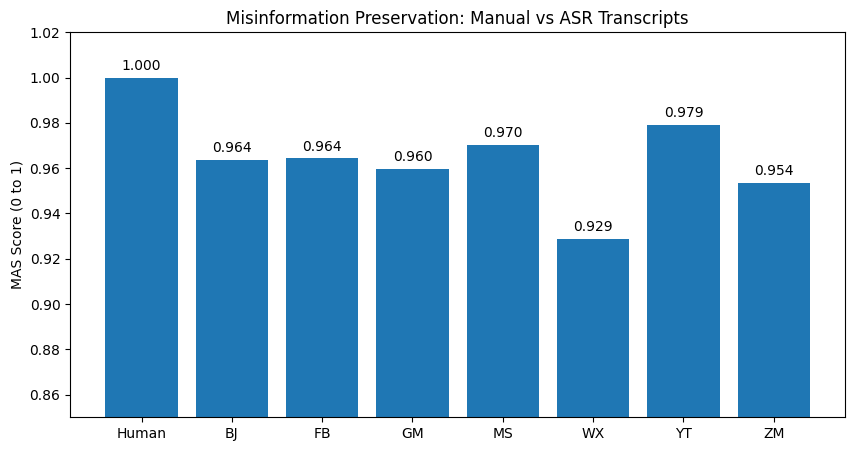

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Manual/reference score for comparison = 1.0 (perfect)
platforms = ['Human'] + agg['platform'].tolist()
mas_scores = [1.0] + agg['MAS_mean'].tolist()

plt.figure(figsize=(10,5))
bars = plt.bar(platforms, mas_scores)

plt.title("Misinformation Preservation: Manual vs ASR Transcripts")
plt.ylabel("MAS Score (0 to 1)")
plt.ylim(0.85, 1.02)

# annotate values
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.002,
             f"{height:.3f}", ha='center', va='bottom')

plt.show()


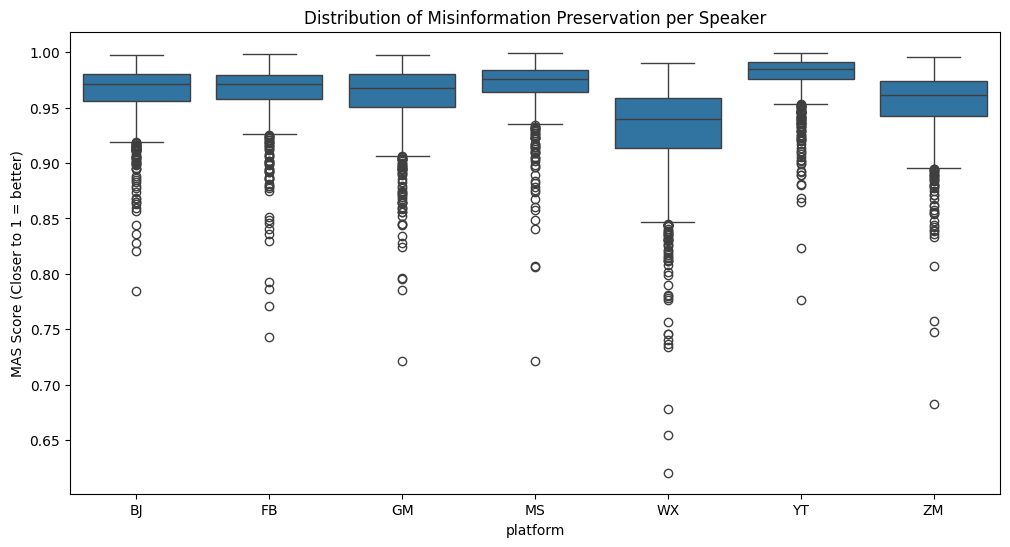

In [31]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=combined, x="platform", y="MAS")
plt.title("Distribution of Misinformation Preservation per Speaker")
plt.ylabel("MAS Score (Closer to 1 = better)")
plt.show()


In [32]:
# What demographics do we actually have?
print("df columns:", df.columns.tolist())

# We'll try to merge whatever exists among these:
cand_demo_cols = ['name', 'gender', 'language', 'wps','race']  # add more here if your df has others
demo_cols = [c for c in cand_demo_cols if c in df.columns]

# Build combined_demo with available demographics
combined_demo = combined.copy()
if 'name' in df.columns and len(demo_cols) > 1:  # name + at least 1 demo col
    combined_demo = combined.merge(df[demo_cols], on='name', how='left')
else:
    print("No demographic columns found in df besides 'name'. Using WPS only if present in combined.")

# Ensure we have WPS buckets
if 'wps_bucket' not in combined_demo.columns:
    if 'wps' in df.columns:
        # make tertiles for WPS
        try:
            combined_demo['wps_bucket'] = pd.qcut(df.set_index('name').loc[combined_demo['name'], 'wps'].values,
                                                  q=3, labels=['slow','normal','fast'])
        except Exception as e:
            print("Could not create wps_bucket:", e)
    else:
        combined_demo['wps_bucket'] = pd.NA

print("combined_demo columns:", combined_demo.columns.tolist())
combined_demo.head(3)

df columns: ['name', 'file', 'transcript', 'text_length', 'age', 'gender', 'race', 'language', 'wps', 'readability', 'f0mean', 'YT_WER', 'FB_WER', 'MS_WER', 'GM_WER', 'WX_WER', 'ZM_WER', 'BJ_WER', 'GM', 'YT', 'MS', 'FB', 'ZM', 'BJ', 'WX', 'ref_lex', 'GM_lex', 'YT_lex', 'MS_lex', 'FB_lex', 'WX_lex', 'ZM_lex', 'BJ_lex', 'wps_bucket']
combined_demo columns: ['name', 'platform', 'TP', 'FN', 'FP', 'keyword_recall', 'keyword_precision', 'keyword_f1', 'semantic_similarity', 'meaning_drift', 'MAS', 'gender', 'language', 'wps', 'race', 'wps_bucket']


,name,platform,TP,FN,FP,keyword_recall,keyword_precision,keyword_f1,semantic_similarity,meaning_drift,MAS,gender,language,wps,race,wps_bucket
0,Aaron Huey,BJ,321,4,4,0.987692,0.987692,0.987692,0.988320,0.011680,0.987943,male,us,2.38,white,slow
1,Aaron Huey,FB,318,7,5,0.978462,0.984520,0.981481,0.975844,0.024156,0.977414,male,us,2.38,white,slow
2,Aaron Huey,GM,316,9,5,0.972308,0.984424,0.978328,0.975498,0.024502,0.973584,male,us,2.38,white,slow


In [33]:
# Platform averages (already in agg)
display(agg.round(4))

# Gender (if available)
if 'gender' in combined_demo.columns:
    gender_tbl = (combined_demo
                  .groupby(['platform','gender'])['MAS']
                  .mean().reset_index()
                  .sort_values(['platform','gender']))
    print("=== MAS by Gender & Platform ===")
    display(gender_tbl.round(4))

# Language (if available)
if 'language' in combined_demo.columns:
    lang_tbl = (combined_demo
                .groupby(['platform','language'])['MAS']
                .mean().reset_index()
                .sort_values(['platform','language']))
    print("=== MAS by Language & Platform ===")
    display(lang_tbl.round(4))
if 'race' in combined_demo.columns:
    race_tbl = (combined_demo
                  .groupby(['platform','race'])['MAS']
                  .mean().reset_index()
                  .sort_values(['platform','race']))
    print("=== MAS by Race & Platform ===")
    display(race_tbl.round(4))

# WPS buckets (we already have)
if 'wps_bucket' in combined_demo.columns:
    wps_tbl = (combined_demo
               .groupby(['platform','wps_bucket'])['MAS']
               .mean().reset_index()
               .sort_values(['platform','wps_bucket']))
    print("=== MAS by WPS Bucket & Platform ===")
    display(wps_tbl.round(4))


,platform,MAS_mean
0,BJ,0.9637
1,FB,0.9645
2,GM,0.9597
3,MS,0.9703
4,WX,0.9288
5,YT,0.9792
6,ZM,0.9536


=== MAS by Gender & Platform ===


,platform,gender,MAS
0,BJ,female,0.9660
1,BJ,male,0.9624
2,FB,female,0.9661
3,FB,male,0.9635
4,GM,female,0.9619
5,GM,male,0.9584
6,MS,female,0.9729
7,MS,male,0.9689
8,WX,female,0.9298
9,WX,male,0.9282


=== MAS by Language & Platform ===


,platform,language,MAS
0,BJ,l2,0.9492
1,BJ,non-us,0.9621
2,BJ,us,0.9690
3,FB,l2,0.9497
4,FB,non-us,0.9679
5,FB,us,0.9676
6,GM,l2,0.9419
7,GM,non-us,0.9613
8,GM,us,0.9646
9,MS,l2,0.9599


=== MAS by Race & Platform ===


,platform,race,MAS
0,BJ,asian,0.9577
1,BJ,black,0.9541
2,BJ,latino,0.9554
3,BJ,white,0.9659
4,FB,asian,0.9558
5,FB,black,0.9608
6,FB,latino,0.9552
7,FB,white,0.9665
8,GM,asian,0.9559
9,GM,black,0.9528


=== MAS by WPS Bucket & Platform ===


/tmp/ipython-input-3275031328.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['platform','wps_bucket'])['MAS']


,platform,wps_bucket,MAS
0,BJ,slow,0.9618
1,BJ,normal,0.9653
2,BJ,fast,0.9639
3,FB,slow,0.9624
4,FB,normal,0.9652
5,FB,fast,0.9658
6,GM,slow,0.9594
7,GM,normal,0.9608
8,GM,fast,0.9588
9,MS,slow,0.9693


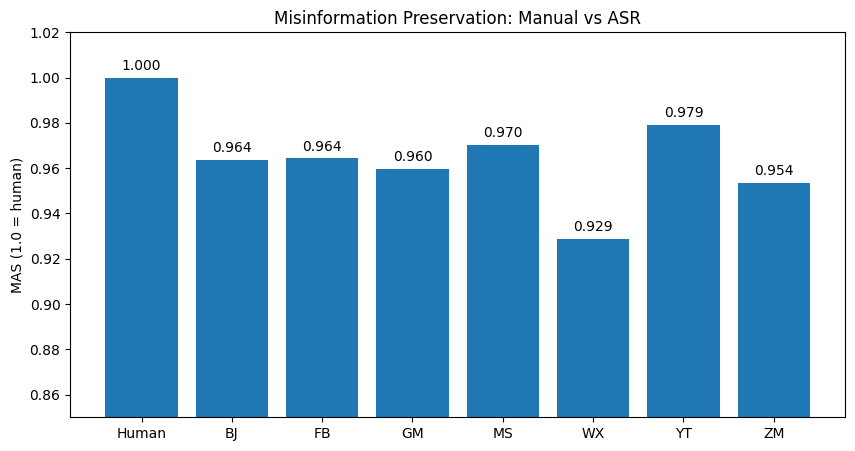

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
platforms = ['Human'] + agg['platform'].tolist()
scores    = [1.0]      + agg['MAS_mean'].tolist()

bars = plt.bar(platforms, scores)
plt.ylim(0.85, 1.02)
plt.title("Misinformation Preservation: Manual vs ASR")
plt.ylabel("MAS (1.0 = human)")
for b in bars:
    h = b.get_height()
    plt.text(b.get_x()+b.get_width()/2, h+0.002, f"{h:.3f}", ha='center', va='bottom')
plt.show()


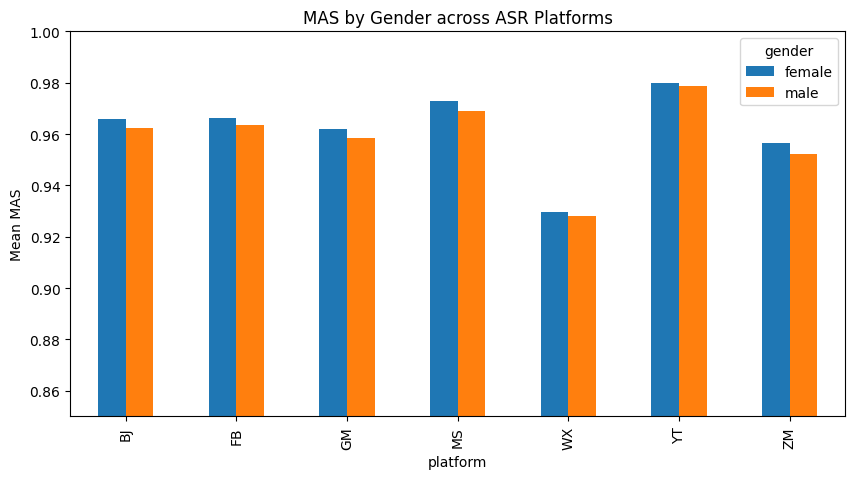

In [35]:
if 'gender' in combined_demo.columns:
    pivot = combined_demo.pivot_table(index='platform', columns='gender', values='MAS', aggfunc='mean')
    pivot = pivot.reindex(index=agg['platform'])  # same platform order as agg
    pivot.plot(kind='bar', figsize=(10,5))
    plt.title("MAS by Gender across ASR Platforms")
    plt.ylabel("Mean MAS")
    plt.ylim(0.85, 1.0)
    plt.show()
else:
    print("No 'gender' column in combined_demo; skipping gender plot.")


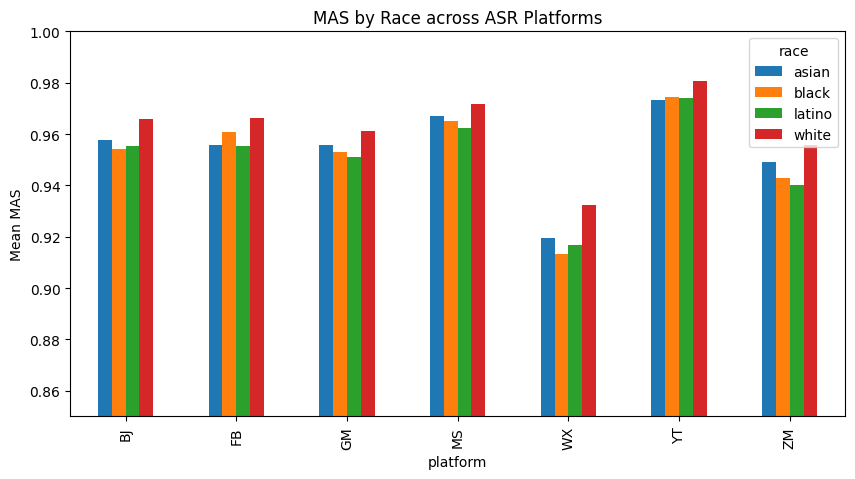

In [36]:
if 'race' in combined_demo.columns:
    pivot = combined_demo.pivot_table(index='platform', columns='race', values='MAS', aggfunc='mean')
    pivot = pivot.reindex(index=agg['platform'])  # keep same platform order
    pivot.plot(kind='bar', figsize=(10,5))
    plt.title("MAS by Race across ASR Platforms")
    plt.ylabel("Mean MAS")
    plt.ylim(0.85, 1.0)
    plt.show()
else:
    print("No 'race' column in combined_demo; skipping race plot.")


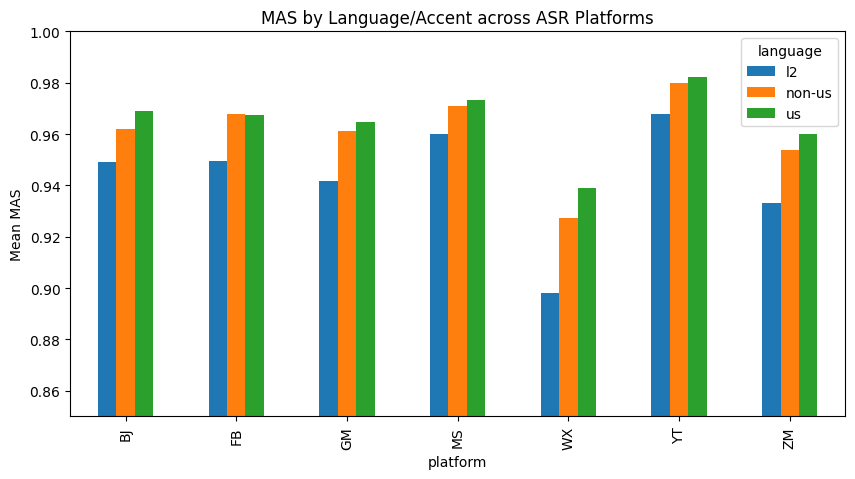

In [37]:
if 'language' in combined_demo.columns:
    pivot = combined_demo.pivot_table(index='platform', columns='language', values='MAS', aggfunc='mean')
    pivot = pivot.reindex(index=agg['platform'])
    pivot.plot(kind='bar', figsize=(10,5))
    plt.title("MAS by Language/Accent across ASR Platforms")
    plt.ylabel("Mean MAS")
    plt.ylim(0.85, 1.0)
    plt.show()
else:
    print("No 'language' column in combined_demo; skipping language plot.")


/tmp/ipython-input-3528210844.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = combined_demo.pivot_table(index='platform', columns='wps_bucket', values='MAS', aggfunc='mean')


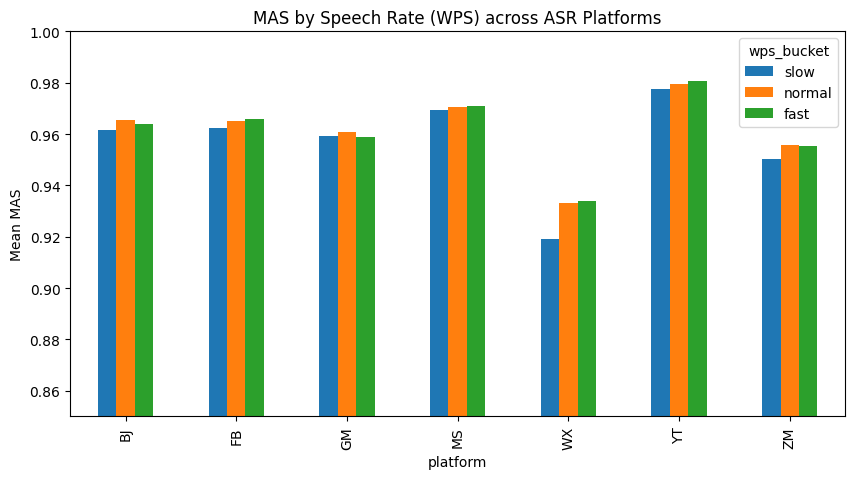

In [38]:
if 'wps_bucket' in combined_demo.columns:
    pivot = combined_demo.pivot_table(index='platform', columns='wps_bucket', values='MAS', aggfunc='mean')
    pivot = pivot.reindex(index=agg['platform'])
    pivot.plot(kind='bar', figsize=(10,5))
    plt.title("MAS by Speech Rate (WPS) across ASR Platforms")
    plt.ylabel("Mean MAS")
    plt.ylim(0.85, 1.0)
    plt.show()
else:
    print("No 'wps_bucket' column available; skipping WPS plot.")


In [39]:
# === Build Final Export Dataset ===

# Merge demo again (to include all possible demographic cols)
demo_cols = [c for c in ['gender','race','language','wps','wps_bucket'] if c in df.columns]
final_export = combined.merge(df[['name'] + demo_cols].drop_duplicates(), on='name', how='left')

# Merge in lexicon match columns (if exist)
lex_cols = [c for c in df.columns if c.endswith("_matched_keywords") or c.endswith("_lex")]
for col in lex_cols:
    if col not in final_export.columns and col in df.columns:
        final_export = final_export.merge(df[['name', col]], on='name', how='left')

# Save to CSV
import os
os.makedirs("/content/misinfo_outputs", exist_ok=True)
export_path = "/content/misinfo_outputs/final_misinformation_dataset.csv"
final_export.to_csv(export_path, index=False)

print("✅ Final dataset created!")
print("📂 Path:", export_path)
print("📏 Rows:", len(final_export))
print("📊 Columns:", len(final_export.columns))
final_export.head()


✅ Final dataset created!
📂 Path: /content/misinfo_outputs/final_misinformation_dataset.csv
📏 Rows: 5922
📊 Columns: 24


,name,platform,TP,FN,FP,keyword_recall,keyword_precision,keyword_f1,semantic_similarity,meaning_drift,...,wps,wps_bucket,ref_lex,GM_lex,YT_lex,MS_lex,FB_lex,WX_lex,ZM_lex,BJ_lex
0,Aaron Huey,BJ,321,4,4,0.987692,0.987692,0.987692,0.988320,0.011680,...,2.38,normal,"{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, fine, witness, past, land, news, army, society, national, history, invited, red,...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, staff, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red..."
1,Aaron Huey,FB,318,7,5,0.978462,0.984520,0.981481,0.975844,0.024156,...,2.38,normal,"{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, fine, witness, past, land, news, army, society, national, history, invited, red,...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, staff, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red..."
2,Aaron Huey,GM,316,9,5,0.972308,0.984424,0.978328,0.975498,0.024502,...,2.38,normal,"{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, land, news, army, society, national, history, invited, red, neede...","{military, black, government, numbers, korea, gone, taken, build, covered, buildings, color, takes, times, created, witness, past, l

In [ ]:
# from google.colab import files
# files.download("/content/misinfo_outputs/final_misinformation_dataset.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
!pip -q install scikit-learn xgboost pandas numpy


In [41]:
df.columns


Index(['name', 'file', 'transcript', 'text_length', 'age', 'gender', 'race',
       'language', 'wps', 'readability', 'f0mean', 'YT_WER', 'FB_WER',
       'MS_WER', 'GM_WER', 'WX_WER', 'ZM_WER', 'BJ_WER', 'GM', 'YT', 'MS',
       'FB', 'ZM', 'BJ', 'WX', 'ref_lex', 'GM_lex', 'YT_lex', 'MS_lex',
       'FB_lex', 'WX_lex', 'ZM_lex', 'BJ_lex', 'wps_bucket'],
      dtype='object')

In [42]:
# create label column from ref_lex
df['label'] = df['ref_lex'].apply(lambda x: 1 if isinstance(x, set) and len(x) > 0 else 0)
print(df['label'].value_counts())


label
1    846
Name: count, dtype: int64


In [43]:
LABEL_COL = 'label'
PLATFORMS = ['GM','YT','MS','FB','WX','ZM','BJ']

need = ['name','transcript', LABEL_COL] + PLATFORMS
missing = [c for c in need if c not in df.columns]
assert not missing, f"Missing columns in df: {missing}"

df = df.dropna(subset=['transcript', LABEL_COL]).copy()
df[LABEL_COL] = df[LABEL_COL].astype(int)

print("Rows in df:", len(df))
print("Columns OK:", need)



Rows in df: 846
Columns OK: ['name', 'transcript', 'label', 'GM', 'YT', 'MS', 'FB', 'WX', 'ZM', 'BJ']


In [44]:
import re
import pandas as pd
import numpy as np

# --- CONFIG ---
MAX_WORDS = 120        # words per chunk
POS_THR   = 2          # positive chunk if it contains >=2 lexicon hits
DROP_COUNT = 1         # drop chunks that have exactly 1 hit (ambiguous)
PLATFORMS = ['GM','YT','MS','FB','WX','ZM','BJ']

# Make sure lexicon exists as a Python list of strings
# If your lexicon variable is different, replace 'lexicon' below.
assert 'lexicon' in globals(), "Missing `lexicon` list. Load your saved lexicon first."

# Precompile a single regex for speed (whole-word, case-insensitive)
lex_sorted = sorted(lexicon, key=len, reverse=True)
safe_terms = [re.escape(t) for t in lex_sorted if t.strip()]
if not safe_terms:
    raise ValueError("Lexicon is empty.")
pattern = re.compile(r'\b(' + r'|'.join(safe_terms) + r')\b', flags=re.IGNORECASE)

def split_into_chunks(text, max_words=MAX_WORDS):
    if not isinstance(text, str) or not text.strip():
        return []
    words = text.split()
    chunks = []
    for i in range(0, len(words), max_words):
        chunk = " ".join(words[i:i+max_words])
        if chunk.strip():
            chunks.append(chunk)
    return chunks

def count_lex_hits(text):
    if not isinstance(text, str) or not text:
        return 0
    return len(pattern.findall(text))

# --- Build chunk dataset from GOLD transcripts ---
rows = []
for _, r in df[['name','transcript']].iterrows():
    name = r['name']
    chunks = split_into_chunks(r['transcript'])
    for j, ch in enumerate(chunks):
        c = count_lex_hits(ch)
        # Positive if >= POS_THR, Negative if == 0, Drop if == DROP_COUNT
        if c == DROP_COUNT:
            continue
        label = 1 if c >= POS_THR else 0
        rows.append({'name': name, 'source': 'REF', 'chunk_id': j, 'text': ch, 'lex_hits': c, 'label': label})

seg_ref = pd.DataFrame(rows)
print("Chunk rows (REF):", len(seg_ref))
print("Label counts (REF):", seg_ref['label'].value_counts().to_dict())
assert seg_ref['label'].nunique() == 2, "Still one class. Relax POS_THR or increase MAX_WORDS."


Chunk rows (REF): 15485
Label counts (REF): {1: 15453, 0: 32}


In [45]:
# 🔹 80–10–10 split on CHUNK DATA (seg_ref)
from sklearn.model_selection import train_test_split
import numpy as np

# Features (texts), labels, and speaker names from seg_ref
X_all     = seg_ref['text']
y_all     = seg_ref['label'].astype(int)
names_all = seg_ref['name']

print("Total chunks:", len(X_all))
print("Label distribution:", np.bincount(y_all))

# Step 1: 80% train, 20% temp (val + test)
X_train, X_temp, y_train, y_temp, names_train, names_temp = train_test_split(
    X_all,
    y_all,
    names_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

# Step 2: split 20% temp into 10% val & 10% test
X_val, X_test, y_val, y_test, names_val, names_test = train_test_split(
    X_temp,
    y_temp,
    names_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Val size:  ", len(X_val))
print("Test size: ", len(X_test))

# Keep TEST speaker names for ASR evaluation later
test_names = set(names_test.tolist())
print("Unique test speakers:", len(test_names))


Total chunks: 15485
Label distribution: [   32 15453]
Train size: 12388
Val size:   1548
Test size:  1549
Unique test speakers: 689


In [46]:
# Cell AJ.1 — TF-IDF for chunk classifier (NEW NAME)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_chunks = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    lowercase=True,
    sublinear_tf=True,
)

X_train_vec = tfidf_chunks.fit_transform(X_train)
X_val_vec   = tfidf_chunks.transform(X_val)
X_test_vec  = tfidf_chunks.transform(X_test)

print("Vectorized shapes (chunks):",
      X_train_vec.shape,
      X_val_vec.shape,
      X_test_vec.shape)


Vectorized shapes (chunks): (12388, 50000) (1548, 50000) (1549, 50000)


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report, recall_score, precision_score
from scipy.sparse import vstack
import numpy as np

base_lr = LogisticRegression(max_iter=1000)

param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'class_weight': ['balanced']
}

grid_lr = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid_lr,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_vec, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best LR CV F1:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_

pred_val_lr = best_lr.predict(X_val_vec)
print("=== Tuned LR Validation ===")
print(classification_report(y_val, pred_val_lr, digits=4))

# retrain on train+val
X_train_full_vec = vstack([X_train_vec, X_val_vec])
y_train_full = np.concatenate([y_train, y_val])

best_lr.fit(X_train_full_vec, y_train_full)

pred_test_lr = best_lr.predict(X_test_vec)
print("=== Tuned LR Test ===")
print(classification_report(y_test, pred_test_lr, digits=4))

baseline_lr = {
    'F1': f1_score(y_test, pred_test_lr),
    'Recall': recall_score(y_test, pred_test_lr),
    'Precision': precision_score(y_test, pred_test_lr, zero_division=0)
}
print("Baseline LR (tuned) on gold test:", baseline_lr)

# this is the model used everywhere later
lr = best_lr


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best LR params: {'C': 100.0, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR CV F1: 0.9992313473652322
=== Tuned LR Validation ===
              precision    recall  f1-score   support

           0     0.4000    0.6667    0.5000         3
           1     0.9994    0.9981    0.9987      1545

    accuracy                         0.9974      1548
   macro avg     0.6997    0.8324    0.7494      1548
weighted avg     0.9982    0.9974    0.9977      1548

=== Tuned LR Test ===
              precision    recall  f1-score   support

           0     0.7500    1.0000    0.8571         3
           1     1.0000    0.9994    0.9997      1546

    accuracy                         0.9994      1549
   macro avg     0.8750    0.9997    0.9284      1549
weighted avg     0.9995    0.9994    0.9994      1549

Baseline LR (tuned) on gold test: {'F1': 0.9996764801035264, 'Recall': 0.999353169469599, 'Precision': 1.0}


In [48]:
# from xgboost import XGBClassifier

# # Handle class imbalance for XGB
# pos = int((y_train == 1).sum())
# neg = int((y_train == 0).sum())
# scale_pos_weight = (neg / max(pos, 1)) if pos > 0 else 1.0

# xgb = XGBClassifier(
#     n_estimators=400,
#     max_depth=6,
#     learning_rate=0.05,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     reg_lambda=1.0,
#     objective='binary:logistic',
#     eval_metric='logloss',
#     n_jobs=-1,
#     random_state=42,
#     scale_pos_weight=scale_pos_weight
# )

# xgb.fit(X_train_vec, y_train)

# print("=== XGB Validation (chunks) ===")
# proba_val_xgb = xgb.predict_proba(X_val_vec)[:,1]
# pred_val_xgb  = (proba_val_xgb >= 0.5).astype(int)
# print(classification_report(y_val, pred_val_xgb, digits=4))

# print("=== XGB Test (chunks) ===")
# proba_test_xgb = xgb.predict_proba(X_test_vec)[:,1]
# pred_test_xgb  = (proba_test_xgb >= 0.5).astype(int)
# print(classification_report(y_test, pred_test_xgb, digits=4))

# baseline_xgb = {
#     'F1': f1_score(y_test, pred_test_xgb),
#     'Recall': recall_score(y_test, pred_test_xgb),
#     'Precision': precision_score(y_test, pred_test_xgb, zero_division=0)
# }
# baseline_xgb
# Cell AY (REPLACE): XGBoost hyperparameter tuning + final model

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score
from scipy.sparse import vstack
import numpy as np

# Handle imbalance: compute scale_pos_weight from train labels
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = (neg / max(pos, 1)) if pos > 0 else 1.0

# Base XGB model (other params will be tuned)
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
)

# Hyperparameter search space
param_dist = {
    "n_estimators":    [200, 400, 600],
    "max_depth":       [3, 5, 7, 9],
    "learning_rate":   [0.02, 0.05, 0.1],
    "subsample":       [0.7, 0.9, 1.0],
    "colsample_bytree":[0.7, 0.9, 1.0],
    "reg_lambda":      [0.5, 1.0, 2.0],
    "min_child_weight":[1, 5, 10],
}

# Randomized hyperparameter search
rand_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,                 # increase if you want more thorough search
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

print("🔎 Tuning XGBoost hyperparameters...")
rand_xgb.fit(X_train_vec, y_train)

print("Best XGB params:", rand_xgb.best_params_)
print("Best XGB CV F1:", rand_xgb.best_score_)

best_xgb = rand_xgb.best_estimator_

# --- Validation performance ---
proba_val_xgb = best_xgb.predict_proba(X_val_vec)[:, 1]
pred_val_xgb  = (proba_val_xgb >= 0.5).astype(int)

print("=== Tuned XGB Validation ===")
print(classification_report(y_val, pred_val_xgb, digits=4))

# --- Retrain on train + val ---
X_train_full_vec = vstack([X_train_vec, X_val_vec])
y_train_full = np.concatenate([y_train, y_val])

best_xgb.fit(X_train_full_vec, y_train_full)

# --- Test performance on gold chunks ---
proba_test_xgb = best_xgb.predict_proba(X_test_vec)[:, 1]
pred_test_xgb  = (proba_test_xgb >= 0.5).astype(int)

print("=== Tuned XGB Test ===")
print(classification_report(y_test, pred_test_xgb, digits=4))

baseline_xgb = {
    'F1': f1_score(y_test, pred_test_xgb),
    'Recall': recall_score(y_test, pred_test_xgb),
    'Precision': precision_score(y_test, pred_test_xgb, zero_division=0),
}

print("Baseline tuned XGB on gold test:", baseline_xgb)

# This is the model used everywhere later
xgb = best_xgb


🔎 Tuning XGBoost hyperparameters...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGB params: {'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best XGB CV F1: 0.9952847328943197
=== Tuned XGB Validation ===
              precision    recall  f1-score   support

           0     0.1250    1.0000    0.2222         3
           1     1.0000    0.9864    0.9932      1545

    accuracy                         0.9864      1548
   macro avg     0.5625    0.9932    0.6077      1548
weighted avg     0.9983    0.9864    0.9917      1548

=== Tuned XGB Test ===
              precision    recall  f1-score   support

           0     0.1667    1.0000    0.2857         3
           1     1.0000    0.9903    0.9951      1546

    accuracy                         0.9903      1549
   macro avg     0.5833    0.9951    0.6404      1549
weighted avg     0.9984    0.9903    0.9938      1549


In [50]:
from sklearn.metrics import f1_score, precision_score, recall_score

def build_seg_asr(plat):
    rows = []
    sub = df[df['name'].isin(test_names)][['name', plat]].copy()
    for _, r in sub.iterrows():
        name = r['name']
        text = r[plat]
        chunks = split_into_chunks(text)
        for j, ch in enumerate(chunks):
            c = count_lex_hits(ch)
            # Apply same drop policy for evaluation labeling to compute metrics vs our test labels:
            # To align labels, we need a "pseudo-gold" label per chunk index from REF.
            rows.append({'name': name, 'platform': plat, 'chunk_id': j, 'text': ch, 'lex_hits': c})
    return pd.DataFrame(rows)

# Build a "gold label map" at (name, chunk_id) from REF test split
gold_test_ref = seg_ref[seg_ref['name'].isin(test_names)].copy()
gold_label_map = gold_test_ref.set_index(['name','chunk_id'])['label']

def score_platform_LR(plat):
    seg_asr = build_seg_asr(plat)
    if seg_asr.empty:
        return None, None
    # keep only rows that exist in REF label map (align by chunk_id)
    idx = []
    y_true = []
    for i, r in seg_asr.iterrows():
        key = (r['name'], r['chunk_id'])
        if key in gold_label_map.index:
            idx.append(i)
            y_true.append(gold_label_map.loc[key])
    if not idx:
        return None, None
    seg_asr = seg_asr.loc[idx].reset_index(drop=True)
    y_true = np.array(y_true, dtype=int)

    Xv = tfidf_chunks.transform(seg_asr['text'].fillna(''))
    y_pred = lr.predict(Xv)

    metrics = {
        'F1': f1_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
    }
    seg_asr['y_true'] = y_true
    seg_asr['y_pred'] = y_pred
    return metrics, seg_asr

rows = []
per_chunk_preds = []
for plat in PLATFORMS:
    m, seg_pred = score_platform_LR(plat)
    if m is not None:
        rows.append({'platform': plat,
                     'LR_F1': m['F1'], 'LR_Recall': m['Recall'], 'LR_Precision': m['Precision'],
                     'LR_F1_drop': baseline_lr['F1'] - m['F1'],
                     'LR_Recall_drop': baseline_lr['Recall'] - m['Recall']})
        seg_pred['platform'] = plat
        per_chunk_preds.append(seg_pred)

asr_chunk_perf = pd.DataFrame(rows).sort_values('LR_F1', ascending=False).reset_index(drop=True)
asr_chunk_preds = pd.concat(per_chunk_preds, ignore_index=True) if per_chunk_preds else pd.DataFrame()
asr_chunk_perf.round(4)


,platform,LR_F1,LR_Recall,LR_Precision,LR_F1_drop,LR_Recall_drop
0,MS,0.9995,0.9995,0.9996,0.0002,-0.0001
1,BJ,0.9993,0.9989,0.9997,0.0004,0.0004
2,GM,0.9993,0.9991,0.9995,0.0004,0.0003
3,YT,0.9992,0.9992,0.9993,0.0005,0.0002
4,WX,0.9992,0.9987,0.9997,0.0005,0.0006
5,ZM,0.9991,0.9990,0.9993,0.0006,0.0004
6,FB,0.9991,0.9987,0.9995,0.0006,0.0006


In [51]:
# Requires your existing agg with ['platform','MAS_mean']
if 'agg' in globals() and {'platform','MAS_mean'}.issubset(set(agg.columns)):
    perf_with_mas = asr_chunk_perf.merge(agg[['platform','MAS_mean']], on='platform', how='left')
    perf_with_mas
else:
    perf_with_mas = asr_chunk_perf.copy()
perf_with_mas


,platform,LR_F1,LR_Recall,LR_Precision,LR_F1_drop,LR_Recall_drop,MAS_mean
0,MS,0.999513,0.999475,0.999550,0.000164,-0.000122,0.970268
1,BJ,0.999323,0.998948,0.999699,0.000353,0.000405,0.963676
2,GM,0.999321,0.999095,0.999547,0.000355,0.000258,0.959675
3,YT,0.999214,0.999176,0.999251,0.000463,0.000177,0.979161
4,WX,0.999210,0.998722,0.999699,0.000466,0.000631,0.928769
5,ZM,0.999100,0.998951,0.999250,0.000576,0.000403,0.953637
6,FB,0.999099,0.998724,0.999474,0.000578,0.000629,0.964451


In [52]:
import os
os.makedirs('/content/misinfo_ml_outputs', exist_ok=True)

seg_ref.to_csv('/content/misinfo_ml_outputs/gold_chunk_dataset.csv', index=False)
asr_chunk_perf.to_csv('/content/misinfo_ml_outputs/asr_chunk_performance.csv', index=False)
perf_with_mas.to_csv('/content/misinfo_ml_outputs/asr_chunk_perf_with_mas.csv', index=False)
asr_chunk_preds.to_csv('/content/misinfo_ml_outputs/asr_per_chunk_predictions.csv', index=False)

print("Saved files in /content/misinfo_ml_outputs")


Saved files in /content/misinfo_ml_outputs


In [53]:
import pandas as pd

print("=== BASELINE (Gold chunks, Logistic Regression) ===")
print(baseline_lr)

print("\n=== ASR platform performance (LR) ===")
display(asr_chunk_perf.round(4))

# If you built perf_with_mas earlier:
if 'perf_with_mas' in globals():
    print("\n=== ASR performance + MAS (alignment) ===")
    display(perf_with_mas.round(4))


=== BASELINE (Gold chunks, Logistic Regression) ===
{'F1': 0.9996764801035264, 'Recall': 0.999353169469599, 'Precision': 1.0}

=== ASR platform performance (LR) ===


,platform,LR_F1,LR_Recall,LR_Precision,LR_F1_drop,LR_Recall_drop
0,MS,0.9995,0.9995,0.9996,0.0002,-0.0001
1,BJ,0.9993,0.9989,0.9997,0.0004,0.0004
2,GM,0.9993,0.9991,0.9995,0.0004,0.0003
3,YT,0.9992,0.9992,0.9993,0.0005,0.0002
4,WX,0.9992,0.9987,0.9997,0.0005,0.0006
5,ZM,0.9991,0.9990,0.9993,0.0006,0.0004
6,FB,0.9991,0.9987,0.9995,0.0006,0.0006



=== ASR performance + MAS (alignment) ===


,platform,LR_F1,LR_Recall,LR_Precision,LR_F1_drop,LR_Recall_drop,MAS_mean
0,MS,0.9995,0.9995,0.9996,0.0002,-0.0001,0.9703
1,BJ,0.9993,0.9989,0.9997,0.0004,0.0004,0.9637
2,GM,0.9993,0.9991,0.9995,0.0004,0.0003,0.9597
3,YT,0.9992,0.9992,0.9993,0.0005,0.0002,0.9792
4,WX,0.9992,0.9987,0.9997,0.0005,0.0006,0.9288
5,ZM,0.9991,0.9990,0.9993,0.0006,0.0004,0.9536
6,FB,0.9991,0.9987,0.9995,0.0006,0.0006,0.9645


In [54]:
import os
os.makedirs('/content/misinfo_ml_outputs', exist_ok=True)

pd.DataFrame([baseline_lr]).to_csv('/content/misinfo_ml_outputs/baseline_LR_gold_chunks.csv', index=False)
asr_chunk_perf.to_csv('/content/misinfo_ml_outputs/asr_chunk_performance_LR.csv', index=False)

if 'perf_with_mas' in globals():
    perf_with_mas.to_csv('/content/misinfo_ml_outputs/asr_chunk_perf_with_mas_LR.csv', index=False)

# Per-chunk predictions (optional but great for case studies)
if 'asr_chunk_preds' in globals() and not asr_chunk_preds.empty:
    asr_chunk_preds.to_csv('/content/misinfo_ml_outputs/asr_chunk_preds_LR.csv', index=False)

print("Saved to /content/misinfo_ml_outputs")


Saved to /content/misinfo_ml_outputs


In [55]:
import numpy as np

# 3a) Correlation with MAS (if available)
if 'perf_with_mas' in globals() and {'MAS_mean'}.issubset(perf_with_mas.columns):
    r = np.corrcoef(perf_with_mas['LR_F1'], perf_with_mas['MAS_mean'])[0,1]
    rd = np.corrcoef(perf_with_mas['LR_F1_drop'], perf_with_mas['MAS_mean'])[0,1]
    print(f"Corr(LR_F1, MAS_mean) = {r:.3f}  |  Corr(LR_F1_drop, MAS_mean) = {rd:.3f} (expect negative)")

# 3b) Correlation with average WER per platform (computed on test speakers)
PLAT_TO_WER = {'YT':'YT_WER','FB':'FB_WER','MS':'MS_WER','GM':'GM_WER','WX':'WX_WER','ZM':'ZM_WER','BJ':'BJ_WER'}

# compute avg WER on the same test set speakers
wer_rows = []
for plat, wer_col in PLAT_TO_WER.items():
    if wer_col in df.columns:
        wer_mean = df[df['name'].isin(test_names)][wer_col].mean()
        wer_rows.append({'platform': plat, 'WER_mean': wer_mean})
wer_df = pd.DataFrame(wer_rows)

# join and correlate
perf_wer = asr_chunk_perf.merge(wer_df, on='platform', how='left')
if 'WER_mean' in perf_wer.columns:
    r2 = np.corrcoef(perf_wer['LR_F1'], perf_wer['WER_mean'])[0,1]
    rd2 = np.corrcoef(perf_wer['LR_F1_drop'], perf_wer['WER_mean'])[0,1]
    print(f"Corr(LR_F1, WER_mean) = {r2:.3f}  |  Corr(LR_F1_drop, WER_mean) = {rd2:.3f} (expect positive for drop)")
    display(perf_wer.round(4))


Corr(LR_F1, MAS_mean) = 0.271  |  Corr(LR_F1_drop, MAS_mean) = -0.271 (expect negative)
Corr(LR_F1, WER_mean) = -0.183  |  Corr(LR_F1_drop, WER_mean) = 0.183 (expect positive for drop)


,platform,LR_F1,LR_Recall,LR_Precision,LR_F1_drop,LR_Recall_drop,WER_mean
0,MS,0.9995,0.9995,0.9996,0.0002,-0.0001,0.0606
1,BJ,0.9993,0.9989,0.9997,0.0004,0.0004,0.0800
2,GM,0.9993,0.9991,0.9995,0.0004,0.0003,0.0879
3,YT,0.9992,0.9992,0.9993,0.0005,0.0002,0.0503
4,WX,0.9992,0.9987,0.9997,0.0005,0.0006,0.1161
5,ZM,0.9991,0.9990,0.9993,0.0006,0.0004,0.0821
6,FB,0.9991,0.9987,0.9995,0.0006,0.0006,0.0686


In [56]:
# 4a) Confusion summary per platform
def confusion_counts(df_pred):
    tp = ((df_pred['y_true']==1) & (df_pred['y_pred']==1)).sum()
    fn = ((df_pred['y_true']==1) & (df_pred['y_pred']==0)).sum()
    fp = ((df_pred['y_true']==0) & (df_pred['y_pred']==1)).sum()
    tn = ((df_pred['y_true']==0) & (df_pred['y_pred']==0)).sum()
    return pd.Series({'TP':tp,'FN':fn,'FP':fp,'TN':tn})

if 'asr_chunk_preds' in globals() and not asr_chunk_preds.empty:
    conf = (asr_chunk_preds.groupby('platform')
            .apply(confusion_counts)
            .reset_index())
    conf['FN_rate_pos'] = conf['FN'] / (conf['FN'] + conf['TP']).replace(0, np.nan)
    conf['FP_rate_neg'] = conf['FP'] / (conf['FP'] + conf['TN']).replace(0, np.nan)
    print("=== Confusion summary per platform (chunk-level) ===")
    display(conf.round(4))

    # 4b) Top false negatives per platform (most harmful misses)
    def top_fns(plat, k=5):
        sub = asr_chunk_preds[(asr_chunk_preds['platform']==plat) & (asr_chunk_preds['y_true']==1) & (asr_chunk_preds['y_pred']==0)]
        return sub[['name','chunk_id','text']].head(k)

    for plat in asr_chunk_perf['platform']:
        print(f"\n--- Top FN examples: {plat} ---")
        display(top_fns(plat, k=5))
else:
    print("No per-chunk predictions found; skip error analysis.")


=== Confusion summary per platform (chunk-level) ===


/tmp/ipython-input-3119921730.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(confusion_counts)


,platform,TP,FN,FP,TN,FN_rate_pos,FP_rate_neg
0,BJ,13291,14,4,7,0.0011,0.3636
1,FB,13306,17,7,3,0.0013,0.7000
2,GM,13252,12,6,7,0.0009,0.4615
3,MS,13337,7,6,10,0.0005,0.3750
4,WX,13286,17,4,9,0.0013,0.3077
5,YT,13345,11,10,12,0.0008,0.4545
6,ZM,13326,14,10,7,0.0010,0.5882



--- Top FN examples: MS ---


,name,chunk_id,text
29024,Chris Downey,15,you haven t quite found yours yet thank you
31010,Fred Swaniker,17,ever seen thank you
32594,Jessa Gamble,5,understand the costs thank you
36213,Paul Ewald,13,to digital thank you very much
36685,Philip Zimbardo,19,it makes strategy interesting again thank you


...

,name,chunk_id,text
54657,Benoit Mandelbrot,20,keep it without end thank you very much
55487,Charles Fleischer,23,number of phase in a year hey you can t make this thank you very much thank you huh
55708,Chris Downey,15,you haven t quite found yours yet oh thank you
57024,Dimitar Sasselov,23,let s hope that we can build this bridge together in the middle thank you very much
57174,Elaine Morgan,19,boat i go along with that too thank you very much



--- Top FN examples: ZM ---


,name,chunk_id,text
67922,Bel Pesce,8,destroy your dreams thank you
69035,Chris Downey,15,set thank you
69265,Colin Powell,26,ours to make sure that no child gets left behind thank you very much
70271,Devdutt Pattanaik,20,you and i only two thank you
70505,Elaine Morgan,20,go home without two thank you very much



--- Top FN examples: FB ---


,name,chunk_id,text
41391,Beth Noveck,24,democracy a better tomorrow thank you
41469,Bill Gross,11,the world that wouldn t have happen otherwise thank you very much my great audience
42157,Charles Fleischer,23,up thank you very much thank you
43223,David Epstein,22,conspired to make athletes stronger faster bolder and better than ever thank you very much
43694,Dimitar Sasselov,23,bridge together and meet in the middle thank you very much


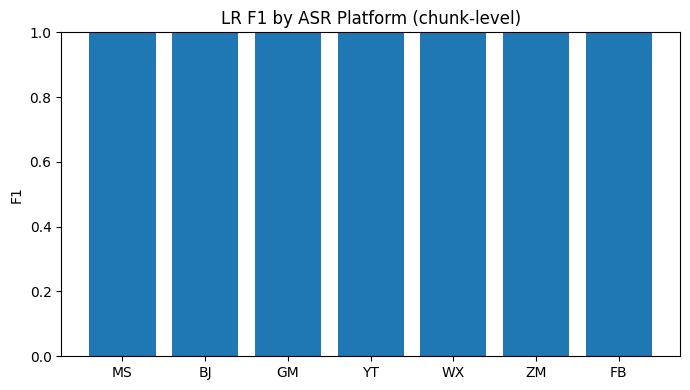

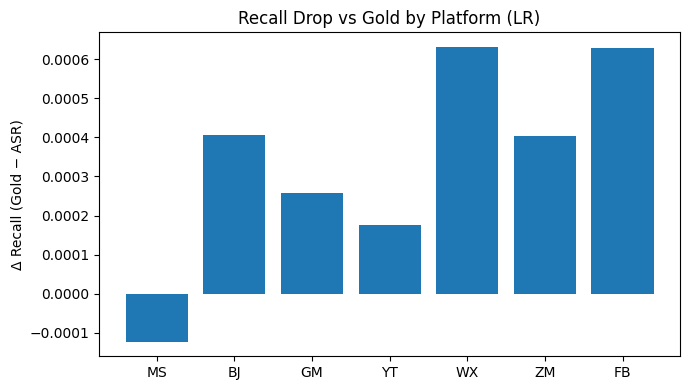

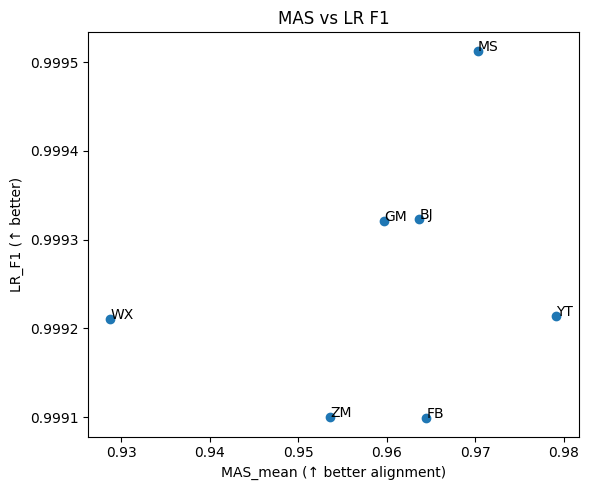

In [57]:
import matplotlib.pyplot as plt

# F1 by platform
plt.figure(figsize=(7,4))
plt.bar(asr_chunk_perf['platform'], asr_chunk_perf['LR_F1'])
plt.title('LR F1 by ASR Platform (chunk-level)')
plt.ylabel('F1')
plt.ylim(0.0, 1.0)
plt.tight_layout()

# Recall drop (harm) by platform
plt.figure(figsize=(7,4))
plt.bar(asr_chunk_perf['platform'], asr_chunk_perf['LR_Recall_drop'])
plt.title('Recall Drop vs Gold by Platform (LR)')
plt.ylabel('Δ Recall (Gold − ASR)')
plt.tight_layout()

plt.savefig("recall_drop_platform.pdf")

# If MAS available: scatter MAS vs LR_F1
if 'perf_with_mas' in globals() and 'MAS_mean' in perf_with_mas.columns:
    plt.figure(figsize=(6,5))
    plt.scatter(perf_with_mas['MAS_mean'], perf_with_mas['LR_F1'])
    for _, r in perf_with_mas.iterrows():
        plt.text(r['MAS_mean'], r['LR_F1'], r['platform'])
    plt.xlabel('MAS_mean (↑ better alignment)')
    plt.ylabel('LR_F1 (↑ better)')
    plt.title('MAS vs LR F1')
    plt.tight_layout()


In [ ]:
# One table: platform, MAS_mean (if present), LR_F1, LR_Recall, LR_F1_drop, LR_Recall_drop, WER_mean (if present)
final = asr_chunk_perf.copy()
if 'perf_with_mas' in globals() and 'MAS_mean' in perf_with_mas.columns:
    final = final.merge(perf_with_mas[['platform','MAS_mean']], on='platform', how='left')
if 'perf_wer' in globals() and 'WER_mean' in perf_wer.columns:
    final = final.merge(perf_wer[['platform','WER_mean']], on='platform', how='left')

final = final[['platform','MAS_mean','WER_mean','LR_F1','LR_Recall','LR_F1_drop','LR_Recall_drop']].copy()
final = final.round(4)
display(final)

final.to_csv('/content/misinfo_ml_outputs/paper_results_table_LR.csv', index=False)
print("Saved: /content/misinfo_ml_outputs/paper_results_table_LR.csv")


,platform,MAS_mean,WER_mean,LR_F1,LR_Recall,LR_F1_drop,LR_Recall_drop
0,MS,0.9703,0.0606,0.9995,0.9995,0.0002,-0.0001
1,BJ,0.9637,0.0800,0.9993,0.9989,0.0004,0.0004
2,GM,0.9597,0.0879,0.9993,0.9991,0.0004,0.0003
3,YT,0.9792,0.0503,0.9992,0.9992,0.0005,0.0002
4,WX,0.9288,0.1161,0.9992,0.9987,0.0005,0.0006
5,ZM,0.9536,0.0821,0.9991,0.9990,0.0006,0.0004
6,FB,0.9645,0.0686,0.9991,0.9987,0.0006,0.0006


Saved: /content/misinfo_ml_outputs/paper_results_table_LR.csv


In [ ]:
# Recreate the fast chunk builder used for LR
def build_seg_asr_fast(plat):
    sub = df[df['name'].isin(test_names)][['name', plat]].copy()
    rows = []
    for _, r in sub.iterrows():
        chunks = split_into_chunks(r[plat])
        if not chunks:
            continue
        rows.extend([
            {'name': r['name'], 'platform': plat, 'chunk_id': j, 'text': ch}
            for j, ch in enumerate(chunks)
        ])
    return pd.DataFrame(rows)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

# Gold label map for chunk alignment (rebuild to be safe)
gold_test_ref = seg_ref[seg_ref['name'].isin(test_names)].copy()
gold_label_map_df = gold_test_ref[['name','chunk_id','label']].rename(columns={'label':'y_true'})

# Fast ASR chunk builder (same as used for LR)
def build_seg_asr_fast(plat):
    sub = df[df['name'].isin(test_names)][['name', plat]].copy()
    rows = []
    for _, r in sub.iterrows():
        chunks = split_into_chunks(r[plat])
        if not chunks:
            continue
        rows.extend([
            {'name': r['name'], 'platform': plat, 'chunk_id': j, 'text': ch}
            for j, ch in enumerate(chunks)
        ])
    return pd.DataFrame(rows)


In [ ]:
from xgboost import XGBClassifier

# Handle imbalance: pos/neg from training labels
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = (neg / max(pos, 1)) if pos > 0 else 1.0

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb.fit(X_train_vec, y_train)

# Baseline on GOLD chunks
proba_ref = xgb.predict_proba(X_test_vec)[:,1]
pred_ref_xgb = (proba_ref >= 0.5).astype(int)

print("=== XGBoost on GOLD chunks ===")
print(classification_report(y_test, pred_ref_xgb, digits=4))

baseline_xgb = {
    'F1': f1_score(y_test, pred_ref_xgb),
    'Recall': recall_score(y_test, pred_ref_xgb),
    'Precision': precision_score(y_test, pred_ref_xgb)
}
baseline_xgb


=== XGBoost on GOLD chunks ===
              precision    recall  f1-score   support

           0     0.1429    1.0000    0.2500         3
           1     1.0000    0.9884    0.9941      1546

    accuracy                         0.9884      1549
   macro avg     0.5714    0.9942    0.6221      1549
weighted avg     0.9983    0.9884    0.9927      1549



{'F1': 0.9941444372153546, 'Recall': 0.9883570504527813, 'Precision': 1.0}

In [ ]:
def xgb_predict_in_batches_proba(texts, batch_size=500):
    probs = []
    n = len(texts)
    for i in range(0, n, batch_size):
        Xv = tfidf_chunks.transform(texts[i:i+batch_size].fillna(''))
        probs.append(xgb.predict_proba(Xv)[:,1])
    return np.concatenate(probs) if probs else np.array([])

def xgb_predict_in_batches(texts, batch_size=500, thr=0.5):
    p = xgb_predict_in_batches_proba(texts, batch_size=batch_size)
    return (p >= thr).astype(int)


In [ ]:
rows_xgb = []
per_chunk_preds_xgb = []

def score_platform_XGB(plat):
    seg_asr = build_seg_asr_fast(plat)
    if seg_asr.empty:
        return None, None
    # Align with gold labels
    seg_asr = seg_asr.merge(gold_label_map_df, on=['name','chunk_id'], how='inner')
    if seg_asr.empty:
        return None, None

    y_true = seg_asr['y_true'].astype(int).values
    y_pred = xgb_predict_in_batches(seg_asr['text'])

    m = {
        'F1': f1_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred)
    }
    seg_asr['y_pred_xgb'] = y_pred
    return m, seg_asr

for plat in PLATFORMS:
    m, seg_pred = score_platform_XGB(plat)
    if m is not None:
        rows_xgb.append({
            'platform': plat,
            'XGB_F1': m['F1'], 'XGB_Recall': m['Recall'], 'XGB_Precision': m['Precision'],
            'XGB_F1_drop': baseline_xgb['F1'] - m['F1'],
            'XGB_Recall_drop': baseline_xgb['Recall'] - m['Recall'],
        })
        per_chunk_preds_xgb.append(seg_pred.assign(platform=plat))

asr_chunk_perf_xgb = pd.DataFrame(rows_xgb).sort_values('XGB_F1', ascending=False).reset_index(drop=True)
asr_chunk_preds_xgb = pd.concat(per_chunk_preds_xgb, ignore_index=True) if per_chunk_preds_xgb else pd.DataFrame()

asr_chunk_perf_xgb.round(4)


,platform,XGB_F1,XGB_Recall,XGB_Precision,XGB_F1_drop,XGB_Recall_drop
0,YT,0.9960,0.9923,0.9997,-0.0018,-0.0039
1,MS,0.9959,0.9923,0.9996,-0.0018,-0.0039
2,GM,0.9956,0.9916,0.9997,-0.0015,-0.0033
3,FB,0.9952,0.9907,0.9998,-0.0011,-0.0023
4,ZM,0.9951,0.9906,0.9997,-0.0010,-0.0022
5,BJ,0.9950,0.9903,0.9998,-0.0009,-0.0019
6,WX,0.9950,0.9902,0.9998,-0.0008,-0.0018


In [ ]:
# Merge per-platform LR and XGB
results_both = asr_chunk_perf.merge(asr_chunk_perf_xgb, on='platform', how='outer')

# Attach MAS if available
if 'agg' in globals() and {'platform','MAS_mean'}.issubset(agg.columns):
    results_both = results_both.merge(agg[['platform','MAS_mean']], on='platform', how='left')

# Attach mean WER on the SAME test speakers
PLAT_TO_WER = {'YT':'YT_WER','FB':'FB_WER','MS':'MS_WER','GM':'GM_WER','WX':'WX_WER','ZM':'ZM_WER','BJ':'BJ_WER'}
wer_rows = []
for plat, wer_col in PLAT_TO_WER.items():
    if wer_col in df.columns:
        wer_rows.append({'platform': plat, 'WER_mean': df[df['name'].isin(test_names)][wer_col].mean()})
wer_df = pd.DataFrame(wer_rows)
if len(wer_df):
    results_both = results_both.merge(wer_df, on='platform', how='left')

# Order columns nicely
cols = ['platform','MAS_mean','WER_mean',
        'LR_F1','LR_Recall','LR_F1_drop','LR_Recall_drop',
        'XGB_F1','XGB_Recall','XGB_F1_drop','XGB_Recall_drop']
results_both = results_both[[c for c in cols if c in results_both.columns]]

display(results_both.round(4))

# Save
import os
os.makedirs('/content/misinfo_ml_outputs', exist_ok=True)
results_both.to_csv('/content/misinfo_ml_outputs/paper_results_table_LR_XGB.csv', index=False)
print("Saved: /content/misinfo_ml_outputs/paper_results_table_LR_XGB.csv")


,platform,MAS_mean,WER_mean,LR_F1,LR_Recall,LR_F1_drop,LR_Recall_drop,XGB_F1,XGB_Recall,XGB_F1_drop,XGB_Recall_drop
0,BJ,0.9637,0.0800,0.9993,0.9989,0.0004,0.0004,0.9950,0.9903,-0.0009,-0.0019
1,FB,0.9645,0.0686,0.9991,0.9987,0.0006,0.0006,0.9952,0.9907,-0.0011,-0.0023
2,GM,0.9597,0.0879,0.9993,0.9991,0.0004,0.0003,0.9956,0.9916,-0.0015,-0.0033
3,MS,0.9703,0.0606,0.9995,0.9995,0.0002,-0.0001,0.9959,0.9923,-0.0018,-0.0039
4,WX,0.9288,0.1161,0.9992,0.9987,0.0005,0.0006,0.9950,0.9902,-0.0008,-0.0018
5,YT,0.9792,0.0503,0.9992,0.9992,0.0005,0.0002,0.9960,0.9923,-0.0018,-0.0039
6,ZM,0.9536,0.0821,0.9991,0.9990,0.0006,0.0004,0.9951,0.9906,-0.0010,-0.0022


Saved: /content/misinfo_ml_outputs/paper_results_table_LR_XGB.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

def per_speaker_metrics(pred_df, model='LR'):
    if pred_df is None or pred_df.empty:
        return pd.DataFrame()
    # ensure needed cols
    need = {'name','platform','y_true'}
    need_pred = f'y_pred' if model=='LR' else 'y_pred_xgb'
    assert need_pred in pred_df.columns
    # compute per (name, platform)
    rows = []
    for (plat, nm), g in pred_df.groupby(['platform','name']):
        y_true = g['y_true'].astype(int).values
        y_pred = g[need_pred].astype(int).values
        if y_true.sum() == 0:  # no positives present → skip recall to avoid div/0
            continue
        rows.append({
            'platform': plat,
            'name': nm,
            f'{model}_Recall': recall_score(y_true, y_pred),
            f'{model}_F1': f1_score(y_true, y_pred),
            f'{model}_Precision': precision_score(y_true, y_pred, zero_division=0)
        })
    return pd.DataFrame(rows)

per_speaker_LR  = per_speaker_metrics(asr_chunk_preds, model='LR') if 'asr_chunk_preds' in globals() else pd.DataFrame()
per_speaker_XGB = per_speaker_metrics(asr_chunk_preds_xgb, model='XGB') if 'asr_chunk_preds_xgb' in globals() else pd.DataFrame()

per_speaker_LR.head(3), per_speaker_XGB.head(3)


(  platform           name  LR_Recall  LR_F1  LR_Precision
 0       BJ     Aaron Huey        1.0    1.0           1.0
 1       BJ   Abha Dawesar        1.0    1.0           1.0
 2       BJ  Abigail Marsh        1.0    1.0           1.0,
   platform           name  XGB_Recall  XGB_F1  XGB_Precision
 0       BJ     Aaron Huey         1.0     1.0            1.0
 1       BJ   Abha Dawesar         1.0     1.0            1.0
 2       BJ  Abigail Marsh         1.0     1.0            1.0)

In [ ]:
from scipy import stats

def anova_by_platform(df_in, col):
    if df_in.empty or col not in df_in.columns:
        return np.nan, np.nan
    groups = [g[col].dropna().values for _, g in df_in.groupby('platform')]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) < 2:
        return np.nan, np.nan
    F, p = stats.f_oneway(*groups)
    return F, p

for metric in ['LR_Recall','LR_F1']:
    F, p = anova_by_platform(per_speaker_LR, metric)
    print(f"ANOVA (LR) {metric}: F={F:.3f}, p={p:.6f} {'✅ sig' if p<0.05 else '❌ ns'}")

if not per_speaker_XGB.empty:
    for metric in ['XGB_Recall','XGB_F1']:
        F, p = anova_by_platform(per_speaker_XGB, metric)
        print(f"ANOVA (XGB) {metric}: F={F:.3f}, p={p:.6f} {'✅ sig' if p<0.05 else '❌ ns'}")


ANOVA (LR) LR_Recall: F=0.503, p=0.806303 ❌ ns
ANOVA (LR) LR_F1: F=0.581, p=0.745774 ❌ ns
ANOVA (XGB) XGB_Recall: F=0.788, p=0.578802 ❌ ns
ANOVA (XGB) XGB_F1: F=0.673, p=0.671671 ❌ ns


In [ ]:
import os
os.makedirs('/content/misinfo_ml_outputs', exist_ok=True)

def top_false_negatives(pred_df, model='LR', k=50):
    if pred_df is None or pred_df.empty:
        return pd.DataFrame()
    yhat_col = 'y_pred' if model=='LR' else 'y_pred_xgb'
    out = []
    for plat, g in pred_df.groupby('platform'):
        sub = g[(g['y_true']==1) & (g[yhat_col]==0)]
        sub = sub[['platform','name','chunk_id','text']].head(k)
        out.append(sub.assign(model=model))
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

fn_lr  = top_false_negatives(asr_chunk_preds, model='LR', k=50) if 'asr_chunk_preds' in globals() else pd.DataFrame()
fn_xgb = top_false_negatives(asr_chunk_preds_xgb, model='XGB', k=50) if 'asr_chunk_preds_xgb' in globals() else pd.DataFrame()
fns = pd.concat([fn_lr, fn_xgb], ignore_index=True) if len(fn_xgb) else fn_lr

fns.to_csv('/content/misinfo_ml_outputs/top_false_negatives_samples.csv', index=False)
print("Saved: /content/misinfo_ml_outputs/top_false_negatives_samples.csv ; rows:", len(fns))


Saved: /content/misinfo_ml_outputs/top_false_negatives_samples.csv ; rows: 442


Saved figures to /content/misinfo_ml_outputs


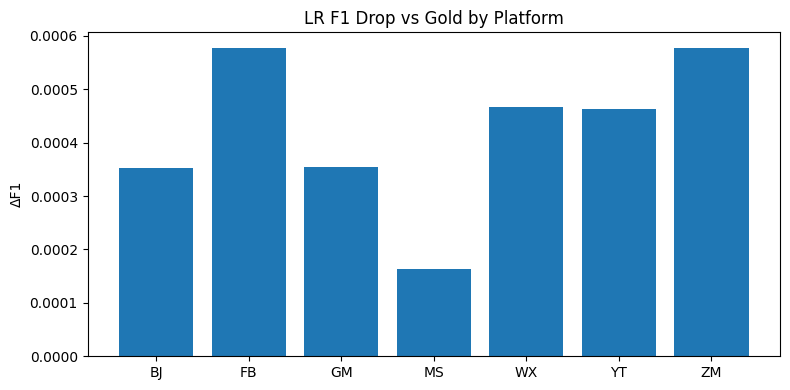

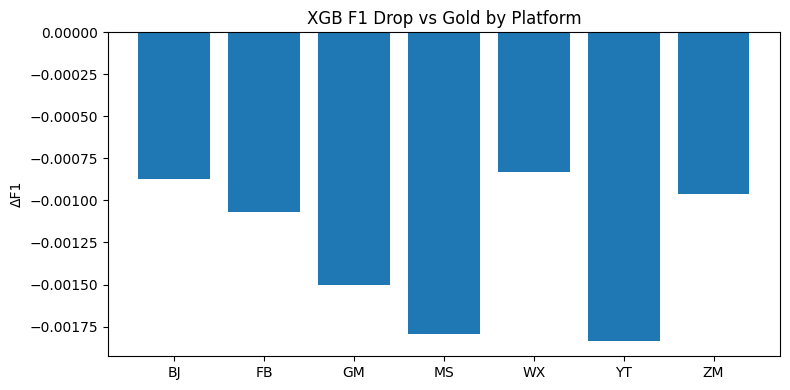

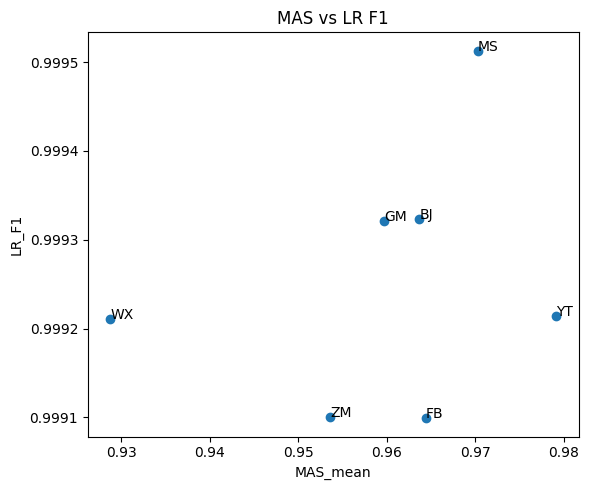

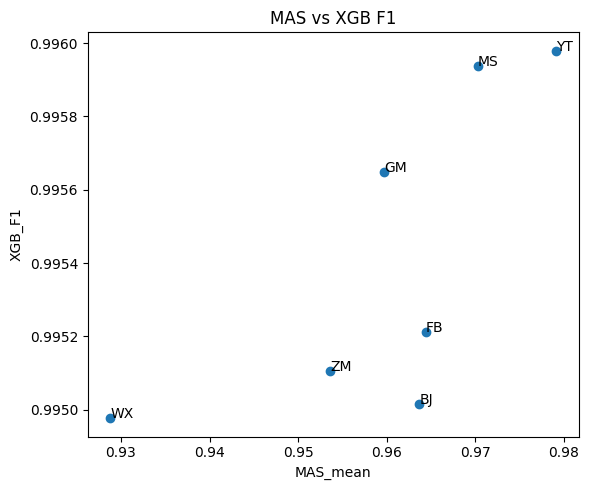

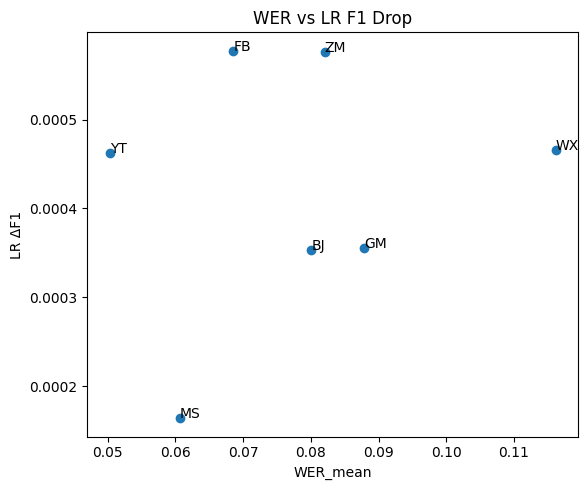

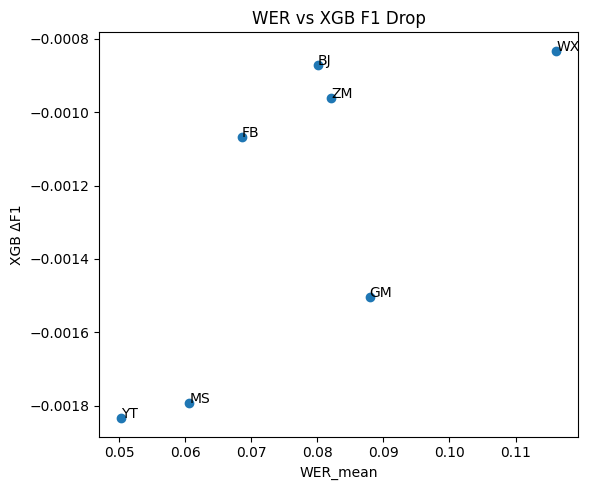

In [ ]:
import matplotlib.pyplot as plt

# 1) F1 drop by platform (LR vs XGB if available)
if 'results_both' in globals():
    plt.figure(figsize=(8,4))
    plt.bar(results_both['platform'], results_both.get('LR_F1_drop', 0))
    plt.title('LR F1 Drop vs Gold by Platform'); plt.ylabel('ΔF1'); plt.tight_layout()
    plt.savefig('/content/misinfo_ml_outputs/fig_LR_f1_drop.png', dpi=300)

    if 'XGB_F1_drop' in results_both.columns:
        plt.figure(figsize=(8,4))
        plt.bar(results_both['platform'], results_both['XGB_F1_drop'])
        plt.title('XGB F1 Drop vs Gold by Platform'); plt.ylabel('ΔF1'); plt.tight_layout()
        plt.savefig('/content/misinfo_ml_outputs/fig_XGB_f1_drop.png', dpi=300)

# 2) MAS vs F1 scatter (LR & XGB)
if 'results_both' in globals() and 'MAS_mean' in results_both.columns:
    if 'LR_F1' in results_both.columns:
        plt.figure(figsize=(6,5))
        plt.scatter(results_both['MAS_mean'], results_both['LR_F1'])
        for _, r in results_both.iterrows():
            plt.text(r['MAS_mean'], r['LR_F1'], r['platform'])
        plt.xlabel('MAS_mean'); plt.ylabel('LR_F1'); plt.title('MAS vs LR F1'); plt.tight_layout()
        plt.savefig('/content/misinfo_ml_outputs/fig_MAS_vs_LR_F1.png', dpi=300)
    if 'XGB_F1' in results_both.columns:
        plt.figure(figsize=(6,5))
        plt.scatter(results_both['MAS_mean'], results_both['XGB_F1'])
        for _, r in results_both.iterrows():
            plt.text(r['MAS_mean'], r['XGB_F1'], r['platform'])
        plt.xlabel('MAS_mean'); plt.ylabel('XGB_F1'); plt.title('MAS vs XGB F1'); plt.tight_layout()
        plt.savefig('/content/misinfo_ml_outputs/fig_MAS_vs_XGB_F1.png', dpi=300)

# 3) WER vs F1 drop scatter
if 'results_both' in globals() and 'WER_mean' in results_both.columns:
    if 'LR_F1_drop' in results_both.columns:
        plt.figure(figsize=(6,5))
        plt.scatter(results_both['WER_mean'], results_both['LR_F1_drop'])
        for _, r in results_both.iterrows():
            plt.text(r['WER_mean'], r['LR_F1_drop'], r['platform'])
        plt.xlabel('WER_mean'); plt.ylabel('LR ΔF1'); plt.title('WER vs LR F1 Drop'); plt.tight_layout()
        plt.savefig('/content/misinfo_ml_outputs/fig_WER_vs_LR_f1drop.png', dpi=300)

    if 'XGB_F1_drop' in results_both.columns:
        plt.figure(figsize=(6,5))
        plt.scatter(results_both['WER_mean'], results_both['XGB_F1_drop'])
        for _, r in results_both.iterrows():
            plt.text(r['WER_mean'], r['XGB_F1_drop'], r['platform'])
        plt.xlabel('WER_mean'); plt.ylabel('XGB ΔF1'); plt.title('WER vs XGB F1 Drop'); plt.tight_layout()
        plt.savefig('/content/misinfo_ml_outputs/fig_WER_vs_XGB_f1drop.png', dpi=300)

print("Saved figures to /content/misinfo_ml_outputs")


In [ ]:
  from sklearn.metrics import f1_score, recall_score, precision_score

def demographic_performance(pred_df, model='LR'):
    if pred_df.empty:
        return pd.DataFrame()
    pred_col = 'y_pred' if model == 'LR' else 'y_pred_xgb'
    rows = []
    for (plat, gender, race, language), g in (
        pred_df.merge(df[['name','gender','race','language']], on='name', how='left')
        .groupby(['platform','gender','race','language'])
    ):
        if g['y_true'].sum() == 0:
            continue
        y_true = g['y_true'].astype(int).values
        y_pred = g[pred_col].astype(int).values
        rows.append({
            'platform': plat,
            'gender': gender,
            'race': race,
            'language': language,
            f'{model}_F1': f1_score(y_true, y_pred),
            f'{model}_Recall': recall_score(y_true, y_pred),
            f'{model}_Precision': precision_score(y_true, y_pred, zero_division=0)
        })
    return pd.DataFrame(rows)

demo_LR  = demographic_performance(asr_chunk_preds, model='LR') if 'asr_chunk_preds' in globals() else pd.DataFrame()
demo_XGB = demographic_performance(asr_chunk_preds_xgb, model='XGB') if 'asr_chunk_preds_xgb' in globals() else pd.DataFrame()

demo_LR.head(3), demo_XGB.head(3)


(  platform  gender   race language     LR_F1  LR_Recall  LR_Precision
 0       BJ  female  asian       l2  1.000000   1.000000           1.0
 1       BJ  female  asian   non-us  1.000000   1.000000           1.0
 2       BJ  female  asian       us  0.998314   0.996633           1.0,
   platform  gender   race language    XGB_F1  XGB_Recall  XGB_Precision
 0       BJ  female  asian       l2  0.995475    0.990991            1.0
 1       BJ  female  asian   non-us  0.975610    0.952381            1.0
 2       BJ  female  asian       us  0.994924    0.989899            1.0)

In [ ]:
from scipy import stats

def demographic_anova(df, model, col):
    if df.empty or col not in df.columns:
        return np.nan, np.nan
    groups = [g[col].dropna().values for _, g in df.groupby(['gender','race','language'])]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) < 2:
        return np.nan, np.nan
    F, p = stats.f_oneway(*groups)
    return F, p

for metric in ['LR_F1','LR_Recall']:
    F, p = demographic_anova(demo_LR, 'LR', metric)
    print(f"ANOVA {metric}: F={F:.3f}, p={p:.6f} {'✅ Significant' if p<0.05 else '❌ Not significant'}")

if not demo_XGB.empty:
    for metric in ['XGB_F1','XGB_Recall']:
        F, p = demographic_anova(demo_XGB, 'XGB', metric)
        print(f"ANOVA {metric}: F={F:.3f}, p={p:.6f} {'✅ Significant' if p<0.05 else '❌ Not significant'}")


ANOVA LR_F1: F=2.016, p=0.007915 ✅ Significant
ANOVA LR_Recall: F=2.038, p=0.007128 ✅ Significant
ANOVA XGB_F1: F=2.517, p=0.000625 ✅ Significant
ANOVA XGB_Recall: F=2.544, p=0.000543 ✅ Significant


In [ ]:
import os
os.makedirs('/content/misinfo_ml_outputs', exist_ok=True)
demo_combined = demo_LR.merge(demo_XGB, on=['platform','gender','race','language'], how='outer')
demo_combined.to_csv('/content/misinfo_ml_outputs/demographic_fairness_results.csv', index=False)
print("Saved: /content/misinfo_ml_outputs/demographic_fairness_results.csv")


Saved: /content/misinfo_ml_outputs/demographic_fairness_results.csv


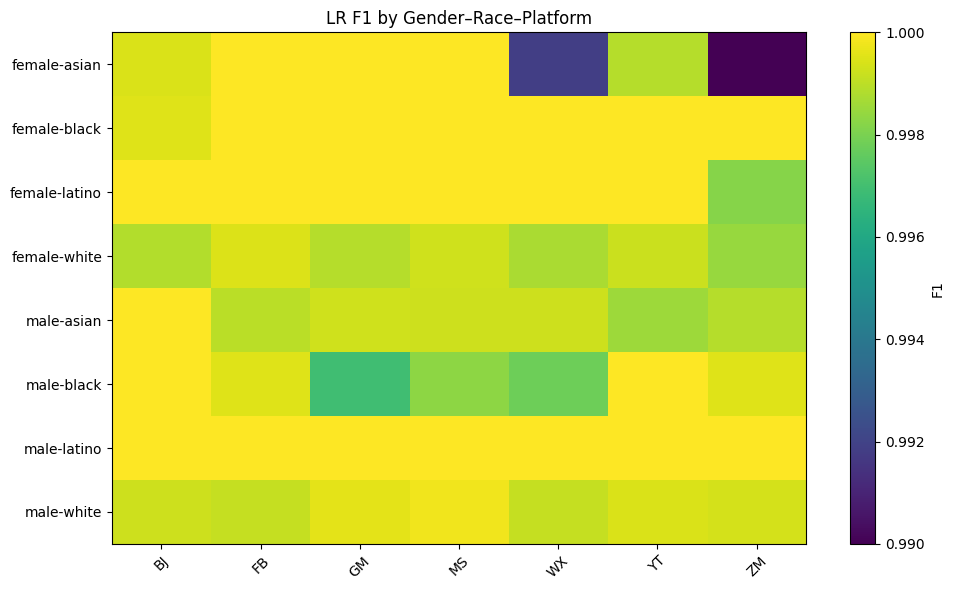

In [ ]:
import matplotlib.pyplot as plt

if not demo_LR.empty:
    pivot = demo_LR.pivot_table(index=['gender','race'], columns='platform', values='LR_F1', aggfunc='mean')
    plt.figure(figsize=(10,6))
    plt.imshow(pivot, aspect='auto')
    plt.title('LR F1 by Gender–Race–Platform')
    plt.colorbar(label='F1')
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
    plt.yticks(range(len(pivot.index)), [f"{g}-{r}" for g, r in pivot.index])
    plt.tight_layout()


In [ ]:
demo_combined.head()

,platform,gender,race,language,LR_F1,LR_Recall,LR_Precision,XGB_F1,XGB_Recall,XGB_Precision
0,BJ,female,asian,l2,1.000000,1.000000,1.0,0.995475,0.990991,1.0
1,BJ,female,asian,non-us,1.000000,1.000000,1.0,0.975610,0.952381,1.0
2,BJ,female,asian,us,0.998314,0.996633,1.0,0.994924,0.989899,1.0
3,BJ,female,black,l2,1.000000,1.000000,1.0,0.995516,0.991071,1.0
4,BJ,female,black,non-us,1.000000,1.000000,1.0,1.000000,1.000000,1.0


In [ ]:
results_both.round(4)

,platform,MAS_mean,WER_mean,LR_F1,LR_Recall,LR_F1_drop,LR_Recall_drop,XGB_F1,XGB_Recall,XGB_F1_drop,XGB_Recall_drop
0,BJ,0.9637,0.0800,0.9993,0.9989,0.0004,0.0004,0.9950,0.9903,-0.0009,-0.0019
1,FB,0.9645,0.0686,0.9991,0.9987,0.0006,0.0006,0.9952,0.9907,-0.0011,-0.0023
2,GM,0.9597,0.0879,0.9993,0.9991,0.0004,0.0003,0.9956,0.9916,-0.0015,-0.0033
3,MS,0.9703,0.0606,0.9995,0.9995,0.0002,-0.0001,0.9959,0.9923,-0.0018,-0.0039
4,WX,0.9288,0.1161,0.9992,0.9987,0.0005,0.0006,0.9950,0.9902,-0.0008,-0.0018
5,YT,0.9792,0.0503,0.9992,0.9992,0.0005,0.0002,0.9960,0.9923,-0.0018,-0.0039
6,ZM,0.9536,0.0821,0.9991,0.9990,0.0006,0.0004,0.9951,0.9906,-0.0010,-0.0022


In [ ]:
platform_rows = []
for plat in PLATFORMS:
    # Select only test samples belonging to this platform
    sub = df[df['name'].isin(test_names)]
    Xp = tfidf_chunks.transform(sub[plat].fillna(''))
    yp_true = sub['label']
    yp_pred_lr = lr.predict(Xp)
    yp_pred_xgb = xgb.predict(Xp)

    platform_rows.append({
        'platform': plat,
        'LR_F1': f1_score(yp_true, yp_pred_lr),
        'LR_Recall': recall_score(yp_true, yp_pred_lr),
        'LR_Precision': precision_score(yp_true, yp_pred_lr),
        'XGB_F1': f1_score(yp_true, yp_pred_xgb),
        'XGB_Recall': recall_score(yp_true, yp_pred_xgb),
        'XGB_Precision': precision_score(yp_true, yp_pred_xgb)
    })

platform_perf = pd.DataFrame(platform_rows)
platform_perf.round(4)


,platform,LR_F1,LR_Recall,LR_Precision,XGB_F1,XGB_Recall,XGB_Precision
0,GM,1.0,1.0,1.0,1.0,1.0,1.0
1,YT,1.0,1.0,1.0,1.0,1.0,1.0
2,MS,1.0,1.0,1.0,1.0,1.0,1.0
3,FB,1.0,1.0,1.0,1.0,1.0,1.0
4,WX,1.0,1.0,1.0,1.0,1.0,1.0
5,ZM,1.0,1.0,1.0,1.0,1.0,1.0
6,BJ,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score
import pandas as pd
import numpy as np

def demo_from_chunk_preds(pred_df, model='LR'):
    # pred_df must contain: ['name','platform','y_true', 'y_pred' or 'y_pred_xgb']
    if pred_df is None or pred_df.empty:
        return pd.DataFrame()
    pred_col = 'y_pred' if model=='LR' else 'y_pred_xgb'
    merged = pred_df.merge(df[['name','gender','race','language']], on='name', how='left')

    rows = []
    for (plat, gdr, rc, lang), g in merged.groupby(['platform','gender','race','language']):
        y_true = g['y_true'].astype(int).values
        y_pred = g[pred_col].astype(int).values
        if y_true.sum() == 0:  # skip groups with no positives
            continue
        rows.append({
            'platform': plat, 'gender': gdr, 'race': rc, 'language': lang,
            f'{model}_F1': f1_score(y_true, y_pred),
            f'{model}_Recall': recall_score(y_true, y_pred),
            f'{model}_Precision': precision_score(y_true, y_pred, zero_division=0)
        })
    return pd.DataFrame(rows)

demo_LR  = demo_from_chunk_preds(asr_chunk_preds, model='LR')
demo_XGB = demo_from_chunk_preds(asr_chunk_preds_xgb, model='XGB')

demo_combined = demo_LR.merge(
    demo_XGB, on=['platform','gender','race','language'], how='outer'
).sort_values(['platform','gender','race','language'])

demo_combined.round(4)


,platform,gender,race,language,LR_F1,LR_Recall,LR_Precision,XGB_F1,XGB_Recall,XGB_Precision
0,BJ,female,asian,l2,1.0000,1.0000,1.0000,0.9955,0.9910,1.0000
1,BJ,female,asian,non-us,1.0000,1.0000,1.0000,0.9756,0.9524,1.0000
2,BJ,female,asian,us,0.9983,0.9966,1.0000,0.9949,0.9899,1.0000
3,BJ,female,black,l2,1.0000,1.0000,1.0000,0.9955,0.9911,1.0000
4,BJ,female,black,non-us,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
...,...,...,...,...,...,...,...,...,...,...
156,ZM,male,latino,l2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
157,ZM,male,latino,us,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
158,ZM,male,white,l2,0.9989,1.0000,0.9978,0.9961,0.9923,1.0000
159,ZM,male,white,non-us,0.9998,1.0000,0.9995,0.9963,0.9930,0.9995


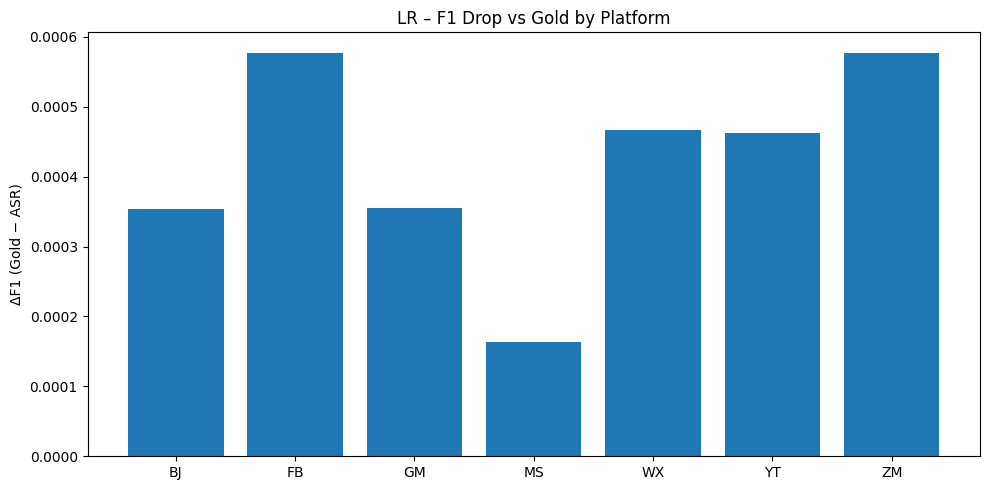

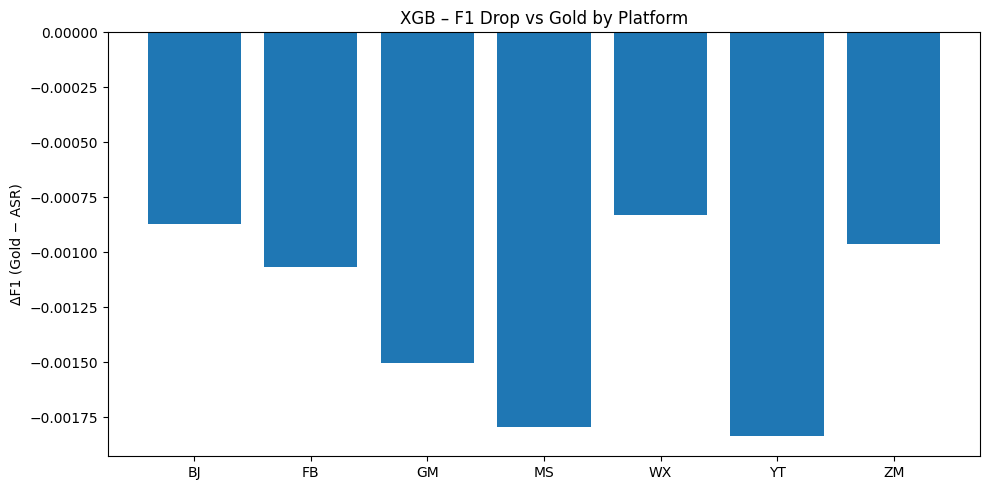

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(results_both['platform'], results_both['LR_F1_drop'])
plt.title('LR – F1 Drop vs Gold by Platform')
plt.ylabel('ΔF1 (Gold − ASR)')
plt.tight_layout()

plt.figure(figsize=(10,5))
plt.bar(results_both['platform'], results_both['XGB_F1_drop'])
plt.title('XGB – F1 Drop vs Gold by Platform')
plt.ylabel('ΔF1 (Gold − ASR)')
plt.tight_layout()


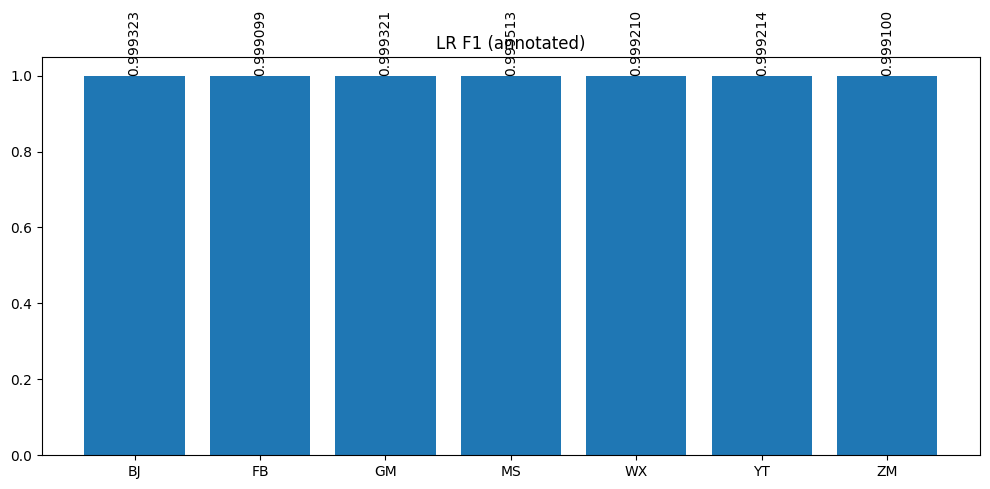

In [ ]:
vals = results_both['LR_F1'].round(6).tolist()
x = np.arange(len(results_both))
plt.figure(figsize=(10,5))
plt.bar(x, results_both['LR_F1'])
for i, v in enumerate(vals):
    plt.text(i, v, f"{v:.6f}", ha='center', va='bottom', rotation=90)
plt.xticks(x, results_both['platform'])
plt.title('LR F1 (annotated)')
plt.tight_layout()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, recall_score, precision_score

# gold test chunks (with text)
gold = seg_ref[seg_ref['name'].isin(test_names)].copy()  # cols: name, chunk_id, text, label
Xg = tfidf_chunks.transform(gold['text'].fillna(''))
gold['y_true'] = gold['label'].astype(int).values
gold['y_pred_lr']  = lr.predict(Xg)
gold['y_pred_xgb'] = xgb.predict(Xg)

# attach demographics
gold = gold.merge(df[['name','gender','race','language']], on='name', how='left')

def metrics_by_demo(df_pred, pred_col):
    rows = []
    for (gdr, rc, lang), g in df_pred.groupby(['gender','race','language']):
        y_true = g['y_true'].astype(int).values
        y_pred = g[pred_col].astype(int).values
        if y_true.sum() == 0:  # no positives to judge recall on
            continue
        rows.append({
            'gender': gdr, 'race': rc, 'language': lang,
            'F1': f1_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows)

gold_demo_LR  = metrics_by_demo(gold, 'y_pred_lr').add_prefix('LR_').rename(columns={'LR_gender':'gender','LR_race':'race','LR_language':'language'})
gold_demo_XGB = metrics_by_demo(gold, 'y_pred_xgb').add_prefix('XGB_').rename(columns={'XGB_gender':'gender','XGB_race':'race','XGB_language':'language'})

gold_demo = gold_demo_LR.merge(gold_demo_XGB, on=['gender','race','language'], how='outer')
gold_demo.head()


,gender,race,language,LR_F1,LR_Recall,LR_Precision,XGB_F1,XGB_Recall,XGB_Precision
0,female,asian,l2,1.0,1.0,1.0,0.993197,0.986486,1.0
1,female,asian,non-us,1.0,1.0,1.0,1.000000,1.000000,1.0
2,female,asian,us,1.0,1.0,1.0,0.991568,0.983278,1.0
3,female,black,l2,1.0,1.0,1.0,0.995516,0.991071,1.0
4,female,black,non-us,1.0,1.0,1.0,1.000000,1.000000,1.0


In [ ]:
def metrics_by_demo_platform(df_pred, model='LR'):
    if df_pred is None or df_pred.empty:
        return pd.DataFrame()
    pred_col = 'y_pred' if model=='LR' else 'y_pred_xgb'
    merged = df_pred.merge(df[['name','gender','race','language']], on='name', how='left')
    rows = []
    for (plat, gdr, rc, lang), g in merged.groupby(['platform','gender','race','language']):
        y_true = g['y_true'].astype(int).values
        y_pred = g[pred_col].astype(int).values
        if y_true.sum() == 0:
            continue
        rows.append({
            'platform': plat, 'gender': gdr, 'race': rc, 'language': lang,
            f'{model}_F1': f1_score(y_true, y_pred),
            f'{model}_Recall': recall_score(y_true, y_pred),
            f'{model}_Precision': precision_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows)

asr_demo_LR  = metrics_by_demo_platform(asr_chunk_preds, model='LR')
asr_demo_XGB = metrics_by_demo_platform(asr_chunk_preds_xgb, model='XGB')
asr_demo = asr_demo_LR.merge(asr_demo_XGB, on=['platform','gender','race','language'], how='outer')

# this is close to the 161-row table you showed
asr_demo.round(4).head()


,platform,gender,race,language,LR_F1,LR_Recall,LR_Precision,XGB_F1,XGB_Recall,XGB_Precision
0,BJ,female,asian,l2,1.0000,1.0000,1.0,0.9955,0.9910,1.0
1,BJ,female,asian,non-us,1.0000,1.0000,1.0,0.9756,0.9524,1.0
2,BJ,female,asian,us,0.9983,0.9966,1.0,0.9949,0.9899,1.0
3,BJ,female,black,l2,1.0000,1.0000,1.0,0.9955,0.9911,1.0
4,BJ,female,black,non-us,1.0000,1.0000,1.0,1.0000,1.0000,1.0


In [ ]:
# asr_demo: per (platform, gender, race, language) metrics from ASR chunk preds
# gold_demo: per (gender, race, language) baselines from GOLD chunk preds

# 1) Merge with explicit suffixes so gold columns become *_gold
demo_drops = asr_demo.merge(
    gold_demo,
    on=['gender','race','language'],
    how='left',
    suffixes=('', '_gold')          # <-- important
)

# 2) Sanity check: which columns do we have?
have = set(demo_drops.columns)
need_asr  = {'LR_F1','LR_Recall','LR_Precision','XGB_F1','XGB_Recall','XGB_Precision'}
need_gold = {c + '_gold' for c in need_asr}
missing = (need_asr | need_gold) - have
if missing:
    print("Missing columns after merge:", missing)

# 3) Compute drops: Drop = GOLD − ASR  (positive = ASR worse than gold)
for m in ['LR_F1','LR_Recall','LR_Precision','XGB_F1','XGB_Recall','XGB_Precision']:
    g = m + '_gold'
    if g in demo_drops.columns and m in demo_drops.columns:
        demo_drops[m + '_drop'] = demo_drops[g] - demo_drops[m]

# 4) Keep only keys + drop columns; sort for readability
keep_cols = ['platform','gender','race','language'] + [c for c in demo_drops.columns if c.endswith('_drop')]
demo_drops = demo_drops[keep_cols].sort_values(['platform','gender','race','language']).reset_index(drop=True)

demo_drops.round(6).head(12)


,platform,gender,race,language,LR_F1_drop,LR_Recall_drop,LR_Precision_drop,XGB_F1_drop,XGB_Recall_drop,XGB_Precision_drop
0,BJ,female,asian,l2,0.000000,0.000000,0.000000,-0.002278,-0.004505,0.000000
1,BJ,female,asian,non-us,0.000000,0.000000,0.000000,0.024390,0.047619,0.000000
2,BJ,female,asian,us,0.001686,0.003367,0.000000,-0.003356,-0.006621,0.000000
3,BJ,female,black,l2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,BJ,female,black,non-us,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,BJ,female,black,us,0.000008,0.000017,0.000000,-0.004321,-0.008579,0.000000
6,BJ,female,latino,l2,0.000000,0.000000,0.000000,0.005525,0.010989,0.000000
7,BJ,female,latino,non-us,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,BJ,female,latino,us,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,BJ,female,white,l2,0.001862,0.003717,0.000000,-0.001855,-0.003690,0.000000


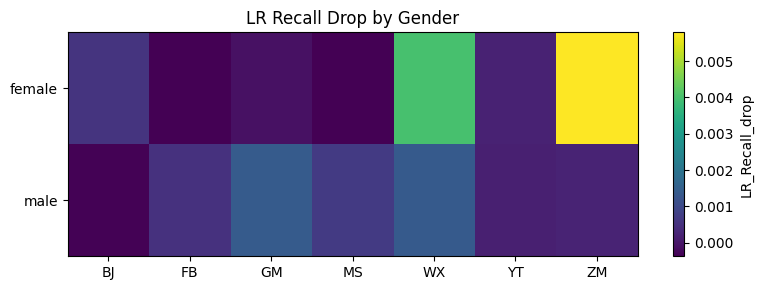

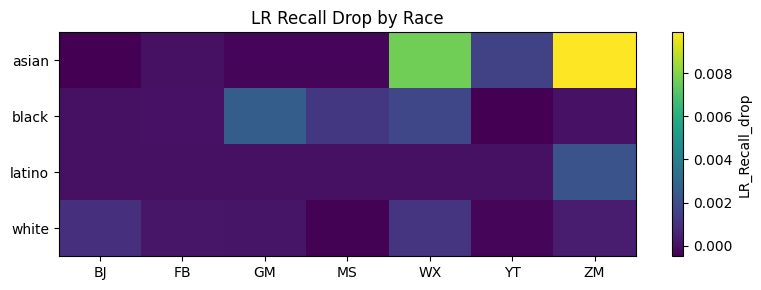

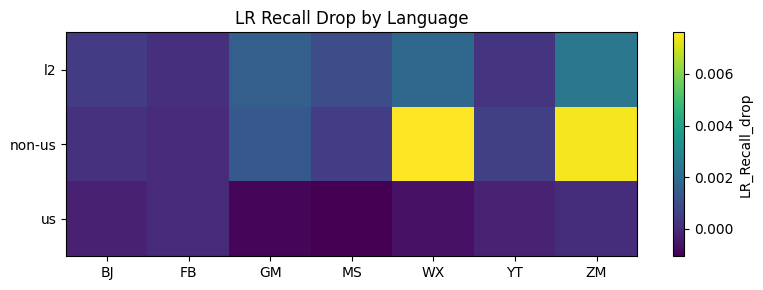

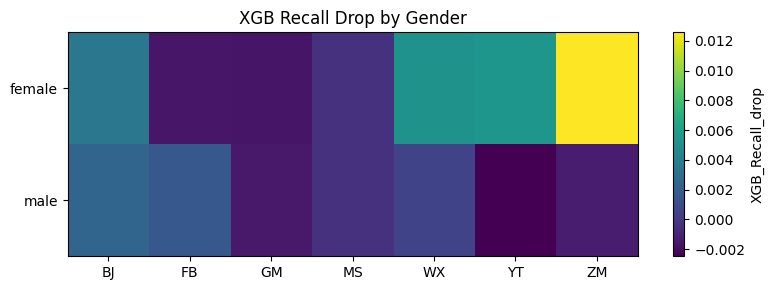

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def heatmap_drop(field, drop_col='LR_Recall_drop', title=None):
    d = demo_drops.copy()
    d = d.groupby(['platform', field])[drop_col].mean().reset_index()
    mat = d.pivot(index=field, columns='platform', values=drop_col).fillna(0.0)

    plt.figure(figsize=(8, max(3, 0.5*len(mat))))
    plt.imshow(mat.values, aspect='auto')
    plt.colorbar(label=drop_col)
    plt.title(title or f'{drop_col} by {field} across Platforms')
    plt.xticks(range(mat.shape[1]), mat.columns, rotation=0)
    plt.yticks(range(mat.shape[0]), mat.index)
    plt.tight_layout()

# Examples
heatmap_drop('gender',   'LR_Recall_drop',  'LR Recall Drop by Gender')
heatmap_drop('race',     'LR_Recall_drop',  'LR Recall Drop by Race')
heatmap_drop('language', 'LR_Recall_drop',  'LR Recall Drop by Language')

# For XGB:
heatmap_drop('gender',   'XGB_Recall_drop', 'XGB Recall Drop by Gender')

In [ ]:
# =========================================================
# MISINFO – 5 PLOTS
#   1) MAS per platform (bar)
#   2) Combined demographic heatmap (Race/Language/Gender × Platform)
#   3) MAS by Race across platforms (grouped bar)
#   4) MAS by Language across platforms (grouped bar)
#   5) MAS by Gender across platforms (grouped bar)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# ---------------------------------------------------------
# 0. CHECK REQUIRED TABLES
# ---------------------------------------------------------
assert 'results_both' in globals(), "results_both (per-platform misinfo metrics) not found."
assert 'combined_demo' in globals(), "combined_demo (demo MAS table) not found."

demo = combined_demo.copy()

# clean categories
demo['race'] = demo['race'].str.lower()
demo['language'] = demo['language'].str.lower()
demo['gender'] = demo['gender'].str.lower()

pdf = PdfPages("MISINFO_5plots.pdf")

platform_order = ['YT', 'FB', 'MS', 'GM', 'WX', 'ZM', 'BJ']

results_plot = results_both.copy()
results_plot = results_plot.set_index('platform').loc[platform_order].reset_index()

# =========================================================
# 1. MAS per platform (overall bar)
# =========================================================
plt.figure(figsize=(8, 4))
plt.bar(results_plot['platform'], results_plot['MAS_mean'])
for x, y in zip(results_plot['platform'], results_plot['MAS_mean']):
    plt.text(x, y + 0.001, f"{y:.3f}", ha='center', va='bottom', fontsize=8)

plt.ylabel("MAS_mean")
plt.xlabel("ASR Platform")
plt.title("Platform-wise Misinformation Alignment Score (MAS)")
plt.ylim(results_plot['MAS_mean'].min() - 0.01,
         results_plot['MAS_mean'].max() + 0.01)
plt.tight_layout()
pdf.savefig(); plt.close()

# =========================================================
# 2. Combined demographic heatmap (Race/Language/Gender × Platform)
# =========================================================
rows = []

# ---- Race × Platform
race_pivot = demo.pivot_table(index='race', columns='platform',
                              values='MAS', aggfunc='mean')
for r in race_pivot.index:
    for p in race_pivot.columns:
        rows.append({
            "group": f"Race: {r.title()}",
            "platform": p,
            "MAS": race_pivot.loc[r, p]
        })

# ---- Language × Platform
lang_pivot = demo.pivot_table(index='language', columns='platform',
                              values='MAS', aggfunc='mean')
for l in lang_pivot.index:
    label = l.upper() if l != 'non-us' else 'Non-US'
    for p in lang_pivot.columns:
        rows.append({
            "group": f"Lang: {label}",
            "platform": p,
            "MAS": lang_pivot.loc[l, p]
        })

# ---- Gender × Platform
gender_pivot = demo.pivot_table(index='gender', columns='platform',
                                values='MAS', aggfunc='mean')
for g in gender_pivot.index:
    for p in gender_pivot.columns:
        rows.append({
            "group": f"Gender: {g.title()}",
            "platform": p,
            "MAS": gender_pivot.loc[g, p]
        })

combined_df = pd.DataFrame(rows)
heat = combined_df.pivot(index='group', columns='platform', values='MAS')

# reorder columns to platform_order if all present
heat = heat[[c for c in platform_order if c in heat.columns]]

plt.figure(figsize=(8, max(4, 0.4 * len(heat.index) + 1)))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Combined Demographic MAS by Platform")
plt.xlabel("Platform")
plt.ylabel("Group")
plt.tight_layout()
pdf.savefig(); plt.close()

# =========================================================
# 3. MAS by Race across ASR platforms (grouped bar)
# =========================================================
race_platform = (
    demo.groupby(['platform', 'race'])['MAS']
    .mean()
    .reset_index()
)

race_order = [r for r in ['asian', 'black', 'latino', 'white'] if r in race_platform['race'].unique()]
if race_order:
    race_platform['race'] = pd.Categorical(race_platform['race'],
                                           categories=race_order,
                                           ordered=True)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=race_platform,
    x='platform',
    y='MAS',
    hue='race',
    order=platform_order
)
plt.ylabel("Mean MAS")
plt.xlabel("Platform")
plt.title("MAS by Race across ASR Platforms")
plt.legend(title="Race")
plt.tight_layout()
pdf.savefig(); plt.close()

# =========================================================
# 4. MAS by Language across ASR platforms (grouped bar)
# =========================================================
lang_platform = (
    demo.groupby(['platform', 'language'])['MAS']
    .mean()
    .reset_index()
)

lang_order = [l for l in ['us', 'non-us', 'l2'] if l in lang_platform['language'].unique()]
if lang_order:
    lang_platform['language'] = pd.Categorical(lang_platform['language'],
                                               categories=lang_order,
                                               ordered=True)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=lang_platform,
    x='platform',
    y='MAS',
    hue='language',
    order=platform_order
)
plt.ylabel("Mean MAS")
plt.xlabel("Platform")
plt.title("MAS by Language across ASR Platforms")
plt.legend(title="Language")
plt.tight_layout()
pdf.savefig(); plt.close()

# =========================================================
# 5. MAS by Gender across ASR platforms (grouped bar)
# =========================================================
gender_platform = (
    demo.groupby(['platform', 'gender'])['MAS']
    .mean()
    .reset_index()
)

# optional nice order
gender_order = [g for g in ['female', 'male'] if g in gender_platform['gender'].unique()]
if gender_order:
    gender_platform['gender'] = pd.Categorical(gender_platform['gender'],
                                               categories=gender_order,
                                               ordered=True)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=gender_platform,
    x='platform',
    y='MAS',
    hue='gender',
    order=platform_order
)
plt.ylabel("Mean MAS")
plt.xlabel("Platform")
plt.title("MAS by Gender across ASR Platforms")
plt.legend(title="Gender")
plt.tight_layout()
pdf.savefig(); plt.close()

# =========================================================
# SAVE & CLOSE PDF
# =========================================================
pdf.close()
print("🎉 DONE! 'MISINFO_5plots.pdf' CREATED SUCCESSFULLY ✅")


🎉 DONE! 'MISINFO_5plots.pdf' CREATED SUCCESSFULLY ✅


In [ ]:
import os
os.listdir()


['.config',
 'misinfo_ml_outputs',
 'MISINFO_selected_plots.pdf',
 'mas_per_platform.pdf',
 'mas_by_wps.pdf',
 'MISINFO_MAS_combined.pdf',
 'MISINFO_results_plots.pdf',
 'mas_vs_wer_corr.pdf',
 'misinfo_cache',
 'misinfo_outputs',
 'MISINFO_5plots.pdf',
 'sample_data']

In [ ]:
from google.colab import files
files.download("MISINFO_5plots.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>